# Introducción al procesamiento de datos radiométricos en aguas continentales

Este cuaderno interactivo aborda la teoría bio-óptica fundamental y el flujo de trabajo metodológico para el procesamiento, calibración radiométrica y análisis de mediciones espectrorradiométricas de campo (*in situ*). Se enfoca en la estimación de la reflectancia de teledetección ($R_{rs}$) y su aplicación al monitoreo de parámetros clave de calidad del agua en lagos y embalses eutróficos.


### Contexto de la campaña de campo: Embalse San Roque (Córdoba, Argentina)

Este cuaderno procesa los datos espectrorradiométricos adquiridos durante la campaña del **27 de octubre de 2022 en el embalse San Roque** (Provincia de Córdoba, Argentina). Las mediciones abarcan 6 estaciones de muestreo limnológico seleccionadas a lo largo del gradiente trófico del reservorio, en el marco del proyecto **PROSAT II-ARG (Programa de Desarrollo de Tecnologías Satelitales - BID N° 4840/OC)**.

El embalse San Roque es un cuerpo de agua templado cálido, monomíctico y predominantemente eutrófico a hipereutrófico, caracterizado por floraciones recurrentes y masivas de cianobacterias potencialmente tóxicas (principalmente *Microcystis aeruginosa*). Por sus características ópticas, constituye un escenario representativo de **aguas Caso 2** (ópticamente complejas), donde los componentes disueltos y particulados varían de manera no covariante con la clorofila-a.

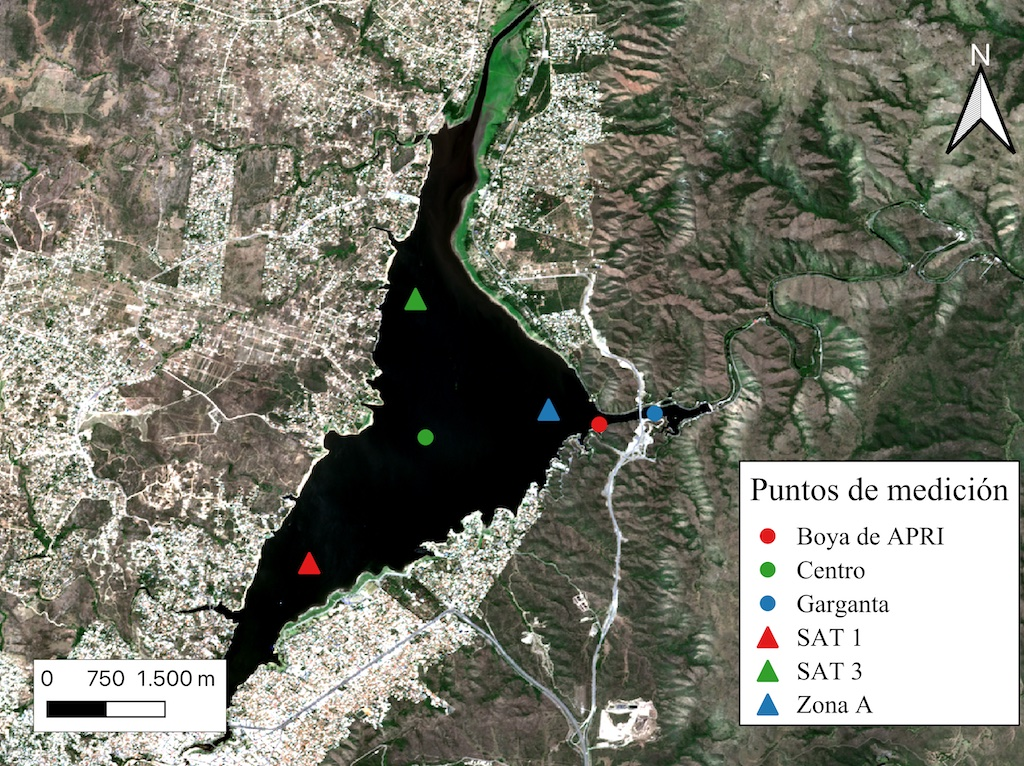


### Flujo de trabajo y objetivos del procesamiento bio-óptico

A lo largo de este cuaderno se desarrollarán secuencialmente las siguientes etapas:

1. **Lectura, calibración y corrección espectral**:
   Transformación de las cuentas crudas del sensor (*Digital Numbers*, $DN$) a magnitudes físicas de radiancia espectral calibrada ($L(\lambda)$ en $\mathrm{W\cdot m^{-2}\cdot nm^{-1}\cdot sr^{-1}}$), corrigiendo las discontinuidades de empalme instrumental (*splice steps*) entre los detectores VNIR y SWIR mediante una corrección parabólica continua.
2. **Cálculo de reflectancias de teledetección ($R_{rs}$)**:
   Estimación de la reflectancia de teledetección sobre la superficie ($R_{rs}(\lambda)$ en $\mathrm{sr^{-1}}$) a partir de la radiancia total emergente ($L_{wat}$), la radiancia difusa del cielo ($L_{sky}$) y la radiancia de un panel de referencia lamberteano de Spectralon ($L_{spc}$), aplicando la corrección de reflexión superficial de Fresnel ($
\rho_F$) dependiente del viento ([Mobley, 1999](https://oceanopticsbook.info/view/surfaces/above-water-rad-measurements)).
3. **Convolución espectral con sensores satelitales**:
   Simulación de las bandas multiespectrales del sensor **Sentinel-3A OLCI** (*Ocean and Land Colour Instrument*) integrando la respuesta espectral relativa ($RSR$) del instrumento.
4. **Modelado bio-óptico y calibración de algoritmos**:
   Ajuste y validación de modelos empíricos y semi-empíricos basados en cocientes de bandas en el rojo y el infrarrojo cercano (Red-NIR) para la estimación cuantitativa de:
   - **Clorofila-a total ($[Chl\text{-}a]$)**: Indicador de biomasa fitoplanctónica general ($R_{rs}(709)/R_{rs}(665)$).
   - **Turbidez**: Indicador de retrodispersión particulada ($R_{rs}(709)$).
   - **Biomasa de cianobacterias**: Cuantificación del pigmento accesorio ficocianina ($R_{rs}(709)/R_{rs}(620)$).


## Instalación de librerías y descarga de datos


### Entorno computacional y dependencias del proyecto

El procesamiento cuantitativo de espectros radiométricos hiperespectrales requiere un ecosistema de librerías científicas optimizadas en Python:
- **NumPy** y **SciPy**: Operaciones matriciales vectorizadas de alto rendimiento, integración numérica trapezoidal (`np.trapezoid`) para la convolución espectral y cálculo de regresiones lineales (`scipy.stats.linregress`) con cuantificación de errores estándar.
- **Pandas** y **Xarray**: Manipulación de datos tabulares y estructuras multidimensionales (curvas RSR de satélite indexadas por longitud de onda y banda).
- **Matplotlib** y **Seaborn**: Generación de figuras científicas de calidad con notación matemática LaTeX y visualización en facetas.
- **asdreader** (`src/asdreader.py`): Módulo especializado para la lectura de la estructura binaria propietaria (`.asd` versión 8) generada por espectrorradiómetros portátiles ASD FieldSpec. Este módulo desempaqueta los metadatos de adquisición (ganancias SWIR, tiempos de integración VNIR, posición GPS, estado de corriente oscura) y los vectores de cuentas espectrales crudas.


In [ ]:
################################################################################
# Descarga y sincronización del repositorio con los datos de campaña
################################################################################
import sys
if 'google.colab' in sys.modules:
    # En caso de ejecutar en un entorno virtual efímero (como Google Colab),
    # clonamos el repositorio para garantizar el acceso a las carpetas data/ y src/
    !rm -r edp2026-radiometria-aguas
    !git clone  --depth 1 https://github.com/fnemina/edp2026-radiometria-aguas

    print("Datos y código sincronizados exitosamente en el entorno de trabajo.")

    # Instalar Contextily
    !pip install contextily -qq
    print("Contextily instalado.")
else:
    print("El entorno de ejecución no es un entorno virtual efímero.")

In [ ]:
################################################################################
# Importación de librerías científicas y módulos locales
################################################################################

# Librerías científicas para cálculo matricial, análisis tabular y estadística
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import xarray as xr
import rasterio
import contextily as cx
from scipy.stats import linregress
from scipy import stats

# Gestión del sistema de archivos y rutas de Python
from pathlib import Path

# Incorporamos la carpeta 'src' al path del sistema para importar asdreader.py
# Compatible tanto para ejecución local en el repositorio como en Google Colab
if Path("src").exists():
    sys.path.append(str(Path("src").resolve()))
else:
    sys.path.append("/content/edp2026-radiometria-aguas/src")

# Módulo local para lectura, decodificación binaria y calibración de archivos ASD
from asdreader import readASD, calibrateASD, parabolicASD


In [ ]:
################################################################################
# Configuración de rutas de datos, unidades radiométricas y rangos espectrales
################################################################################

# Detección dinámica de la ruta de datos (entorno local o Colab)
if Path("data").exists():
    data_path = Path("data")
else:
    data_path = Path("/content/edp2026-radiometria-aguas/data")

rad_path = data_path / "radiometricos"
com_path = data_path / "complemetarios"

# Notación de unidades radiométricas en formato LaTeX para gráficos científicos
I_units = r"$\mathrm{W\cdot m^{-2}\cdot nm^{-1}}$"            # Irradiancia espectral
L_units = r"$\mathrm{W\cdot m^{-2}\cdot nm^{-1}\cdot sr^{-1}}$"  # Radiancia espectral

# Mapeo de códigos de sufijo en nombres de archivo a descripciones en español
nombre_tipos = {"sky": "Cielo", "spc": "Spectralon", "wat": "Agua"}

# Rango espectral útil para aguas continentales (filtrando extremos de baja relación señal/ruido)
wl_min = 400
wl_max = 850

# Longitud de onda para corrección de Glint remanente
wl_glint = 1200.0

# Longitud de onda y numero de desvios de la media a conservar
wl_var = 550.0
K = 1


## 1. Lectura de datos y calibración radiométrica

### Fundamentos de la espectrorradiometría de campo

En teledetección acuática (*ocean color remote sensing*), las mediciones radiométricas *in situ* representan el estándar de verdad terreno (*ground truth*) indispensable para la calibración y validación de sensores satelitales.

Los espectrorradiómetros de campo portátiles (como la serie **ASD FieldSpec**) miden el flujo radiante captado por una fibra óptica con campo de visión conocido (*FOV*), dispersando la radiación electromagnética mediante redes de difracción holográficas hacia arreglos de detectores de estado sólido.

La salida inicial del instrumento consiste en **números digitales** (*Digital Numbers*, $DN$), valores enteros proporcionales a la acumulación de fotoelectrones generados en los detectores. Para que estos datos adquieran significado físico y bio-óptico comparable internacionalmente, deben ser transformados a **radiancia espectral absoluta** ($L(\lambda)$ en $\mathrm{W\cdot m^{-2}\cdot nm^{-1}\cdot sr^{-1}}$) mediante coeficientes de calibración trazables a patrones primarios ([Mobley et al., Ocean Optics Web Book](https://oceanopticsbook.info/view/overview-of-optical-oceanography/introduction)).


### 1.1 Lectura y consulta de datos crudos

El espectrorradiómetro ASD FieldSpec cubre un intervalo espectral continuo desde los 350 hasta los 2500 nm mediante tres subsistemas detectores complementarios:
1. **VNIR (350 - 1000 nm)**: Arreglo lineal de 512 fotodiodos de silicio (Si). Corresponde al rango visible y de infrarrojo cercano, fundamental para estudiar la absorción y dispersión del fitoplancton, la materia orgánica disuelta y los sedimentos.
2. **SWIR1 (1001 - 1800 nm)**: Espectrómetro de barrido rápido con fotodetector de InGaAs termorregulado.
3. **SWIR2 (1801 - 2500 nm)**: Espectrómetro de barrido rápido con fotodetector de InGaAs termorregulado.

El archivo binario `.asd` almacena la respuesta espectral en cuentas crudas ($DN$) junto con una cabecera de 484 bytes que contiene metadatos esenciales: tiempo de integración del detector VNIR, ganancias y desplazamientos (*offsets*) de los detectores SWIR, calibración espectral de longitud de onda, coordenadas GPS y marcas temporales.


In [ ]:
# Lectura del archivo binario crudo (.asd) correspondiente al punto 1 (panel de referencia Spectralon)
DN = readASD(rad_path / "punto-1" / "185-20221027-ESR-01-000-spc.asd")

# Mostrar metadatos instrumentales extraídos de la cabecera binaria
print("=== Metadatos del instrumento ASD FieldSpec ===")
print(DN.metadata)

# Extraer el vector de longitudes de onda (nm) y las cuentas digitales crudas (DN)
wl = DN.wave
dn = DN.spectrum

# Visualización del espectro crudo en cuentas digitales
plt.figure(figsize=(9, 5))
DN.plot()
plt.xlabel("Longitud de onda [nm]")
plt.ylabel("Cuentas digitales [DN]")
plt.title("Espectro crudo en números digitales (DN) - Panel de referencia")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


### 1.2 Calibración radiométrica absoluta

La calibración radiométrica consiste en relacionar linealmente las cuentas digitales medidas en campo ($DN$) con la radiancia espectral física ($L$). Para ello se utiliza la calibración de laboratorio obtenida iluminando un panel blanco estándar de reflectancia conocida con una lámpara halógena de irradiancia espectral calibrada y trazable al NIST:

$$
L(\lambda) = \frac{\mathrm{ref}(\lambda) \times \mathrm{ill}(\lambda) \times [DN(\lambda) - OF(\lambda)]}{\pi \times [\mathrm{raw}(\lambda) - OF_r(\lambda)]} \times \frac{IG_r(\lambda)}{IG(\lambda)}
$$

donde:
- $L(\lambda)$: Radiancia espectral medida por el sensor en campo ($\mathrm{W\cdot m^{-2}\cdot nm^{-1}\cdot sr^{-1}}$).
- $\mathrm{ref}(\lambda)$: Factor de reflectancia espectral calibrado del panel difusor blanco de laboratorio (Spectralon, adimensional, $\approx 0.99$).
- $\mathrm{ill}(\lambda)$: Irradiancia espectral absoluta emitida por la lámpara patrón calibrada a la distancia de trabajo ($\mathrm{W\cdot m^{-2}\cdot nm^{-1}}$).
- $DN(\lambda)$: Cuentas digitales registradas durante la medición de campo.
- $\mathrm{raw}(\lambda)$: Cuentas digitales registradas por el instrumento al medir el panel de referencia en el laboratorio de calibración.
- $OF(\lambda)$ y $OF_r(\lambda)$: Señal de corriente oscura (*dark current offsets*) del instrumento en campo y en laboratorio, respectivamente.
- $\pi$: Factor de conversión del ángulo sólido para un reflector lamberteano perfecto (estereorradianes, $\mathrm{sr}$), dado que $E = \pi L$.
- $IG(\lambda)$ e $IG_r(\lambda)$: Factores de ganancia y tiempo de integración correspondientes a la medición de campo y a la calibración de laboratorio, los cuales corrigen la proporcionalidad lineal de respuesta del sensor frente al tiempo de exposición fotométrica.


In [ ]:
# Carga de los archivos de calibración absoluta de fábrica del instrumento:
# - BSE182853.ref: Curva de reflectancia espectral calibrada del panel de referencia de laboratorio
# - LMP182853.ill: Irradiancia espectral absoluta de la lámpara patrón trazable a NIST (W/m^2/nm)
# - Ni182853.raw: Respuesta en cuentas crudas (DN) del instrumento en el banco de calibración
ref = readASD(com_path / "calibracion" / "BSE182853.ref")
ill = readASD(com_path / "calibracion" / "LMP182853.ill")
raw = readASD(com_path / "calibracion" / "Ni182853.raw")


In [ ]:
# @title
# Gráfico comparativo de las tres magnitudes instrumentales de calibración de laboratorio
fig, ax_ref = plt.subplots(figsize=(10, 6))

# 1. Creación de ejes coordenados gemelos para variables con diferentes unidades y escalas
ax_raw = ax_ref.twinx()  # Eje 'y' derecho para las cuentas crudas de calibración (DN)
ax_ill = ax_ref.twinx()  # Eje 'y' secundario izquierdo para la irradiancia espectral

# 2. Desplazamiento del eje secundario izquierdo hacia afuera para asegurar legibilidad
ax_ill.spines["left"].set_position(("outward", 65))
ax_ill.spines["left"].set_visible(True)
ax_ill.yaxis.set_label_position("left")
ax_ill.yaxis.set_ticks_position("left")
ax_ill.spines["right"].set_visible(False)

# 3. Graficado de los datos con colores diferenciados
c_ref, c_ill, c_raw = "C0", "C1", "C2"

(l1,) = ax_ref.plot(ref.wave, ref.spectrum, color=c_ref, label="Reflectancia del panel (ref)")
(l2,) = ax_ill.plot(ill.wave, ill.spectrum, color=c_ill, label="Irradiancia de la lámpara (ill)")
(l3,) = ax_raw.plot(raw.wave, raw.spectrum, color=c_raw, label="Cuentas crudas de calibración (raw)")

# 4. Configuración de etiquetas de ejes, marcas y escalas
ax_ref.set_xlabel("Longitud de onda [nm]")

# Eje primario izquierdo: Reflectancia espectral del panel (adimensional)
ax_ref.set_ylabel("Reflectancia [adimensional]", color=c_ref)
ax_ref.tick_params(axis="y", colors=c_ref)
ax_ref.spines["left"].set_color(c_ref)

# Eje secundario izquierdo: Irradiancia espectral de la lámpara (W/m^2/nm)
ax_ill.set_ylabel(f"Irradiancia [{I_units}]", color=c_ill)
ax_ill.tick_params(axis="y", colors=c_ill)
ax_ill.spines["left"].set_color(c_ill)

# Eje derecho: Cuentas digitales de calibración (DN)
ax_raw.set_ylabel("Cuentas digitales [DN]", color=c_raw)
ax_raw.tick_params(axis="y", colors=c_raw)
ax_raw.spines["right"].set_color(c_raw)

# 5. Construcción de una leyenda unificada para los tres ejes
lines = [l1, l2, l3]
labels = [l.get_label() for l in lines]
ax_ref.legend(lines, labels, loc="upper right")

ax_ref.set_title("Magnitudes de referencia para la calibración radiométrica del ASD FieldSpec")
fig.tight_layout()
plt.show()


In [ ]:
# Aplicación de la ecuación de calibración radiométrica a las cuentas medidas en campo
L = calibrateASD(DN, ref, ill, raw)

# Graficado del espectro resultante en unidades físicas de radiancia espectral
plt.figure(figsize=(9, 5))
L.plot()
plt.xlabel("Longitud de onda [nm]")
plt.ylabel(f"Radiancia espectral $L$ [{L_units}]")
plt.title("Radiancia espectral calibrada ($L$)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


### 1.3 Corrección parabólica de empalmes espectrales (Splice Correction)

Los espectrorradiómetros ASD FieldSpec integran tres detectores ópticos independientes alimentados por un haz bifurcado de fibra óptica:
- **Empalme 1 ($\lambda \approx 1000\text{ nm}$)**: Frontera entre el arreglo de fotodiodos VNIR de silicio (Si) y el primer detector SWIR1 de InGaAs.
- **Empalme 2 ($\lambda \approx 1800\text{ nm}$)**: Frontera entre el detector SWIR1 y el detector SWIR2 de InGaAs.

En condiciones reales de campo, las diferencias de coeficiente de temperatura entre los materiales semiconductores (Si vs. InGaAs), las variaciones térmicas del chasis o pequeñas derivas en las ganancias electrónicas introducen discontinuidades o escalones verticales espurios (*splice steps* o *step errors*) en las longitudes de onda de transición.

La **corrección parabólica** (`parabolicASD`) modela un ajuste polinomial cuadrático que interpola suavemente el desfase entre las longitudes de onda de empalme y los puntos de referencia espectral adyacentes ($x_{v1} = 675\text{ nm}$ y $x_{v2} = 1975\text{ nm}$), restaurando la continuidad espectral sin alterar la forma bio-óptica ni la amplitud de las bandas de absorción ([Hu et al., 2012](https://doi.org/10.1364/AO.51.006045)).


In [ ]:
# Aplicación de la corrección parabólica para eliminar el escalón de empalme en 1000 nm
Lp = parabolicASD(L)

# Comparación gráfica del espectro antes y después de la corrección parabólica
plt.figure(figsize=(9, 5))
L.plot(label="Radiancia original (L)", alpha=0.7, color="tab:blue")
Lp.plot(label="Radiancia con corrección parabólica (Lp)", linestyle="--", color="tab:red")
plt.legend()
plt.xlabel("Longitud de onda [nm]")
plt.ylabel(f"Radiancia espectral $L$ [{L_units}]")
plt.title("Efecto de la corrección parabólica en el empalme de detectores (1000 nm)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


### 1.4 Procesamiento automatizado y promedio espectral por estación de muestreo

En la radiometría sobre la superficie del agua (*above-water radiometry*), las fluctuaciones dinámicas inducidas por las olas de capilaridad y gravedad generan variaciones rápidas en la reflexión especular de la radiación solar (*sun glint*), mientras que el movimiento de la embarcación y las variaciones en la cobertura nubosa introducen ruido aleatorio en las mediciones individuales.

Siguiendo los protocolos de adquisición de la NASA y la comunidad oceanográfica internacional ([Mobley, 1999](https://oceanopticsbook.info/view/surfaces/above-water-rad-measurements); [Ruddick et al., 2006](https://doi.org/10.4319/lo.2006.51.2.1167)), en cada estación se registran múltiples réplicas espectrales consecutivas para cada uno de los tres blancos fundamentales:
1. **Panel de Spectralon** ($L_{spc}$): Para medir la irradiancia descendente que ilumina la superficie.
2. **Cielo difuso** ($L_{sky}$): Para cuantificar la radiancia incidente del cielo en la dirección especular de reflexión.
3. **Superficie del agua** ($L_{wat}$): Para medir la radiancia total emergente hacia el detector.

El promedio de estas réplicas permite filtrar los picos espurios de destello solar (*glint*) y obtener un espectro representativo y de alta relación señal/ruido para cada estación.


In [ ]:
# Listas para almacenar los espectros calibrados y los identificadores de punto y tipo
spectra_list = []
index_list = []
wavelengths = None

# Recorremos recursivamente todos los archivos .asd en la carpeta de datos radiométricos
for file_path in rad_path.rglob("*.asd"):
    # Extraemos el tipo de medición ('wat', 'sky', 'spc') a partir del nombre del archivo
    kind = file_path.name.removesuffix(".asd").split("-")[-1]
    # Extraemos el número del punto de muestreo a partir del nombre de la carpeta contenedora
    point = str(file_path).split("/")[-2].split("-")[-1]

    row_name = f"{point}-{kind}"

    # Lectura del archivo binario y aplicación de calibración radiométrica y corrección parabólica
    _DN = readASD(file_path)
    _L = calibrateASD(_DN, ref, ill, raw)
    _Lp = parabolicASD(_L)

    # Capturamos el vector de longitudes de onda una única vez
    if wavelengths is None:
        wavelengths = _Lp.wave

    # Añadimos el array espectral y el identificador a las listas de acumulación
    spectra_list.append(_Lp.spectrum)
    index_list.append(row_name)

# Construcción de un DataFrame consolidado con todos los espectros procesados
L_dataframe = pd.DataFrame(spectra_list, index=index_list, columns=wavelengths)
L_dataframe = L_dataframe.sort_index()

# Corrección por glint solo para el agua
mask = L_dataframe.index.str.contains('wat', case=False, na=False)
L_dataframe.loc[mask] = L_dataframe.loc[mask].sub(L_dataframe.loc[mask, wl_glint], axis=0)

# Restringimos el intervalo espectral al rango útil de interés bio-óptico (350 - 900 nm)
L_dataframe = L_dataframe.T.loc[wl_min:wl_max].T
print(f"Espectros procesados exitosamente: {L_dataframe.shape[0]} mediciones individuales.")

# Calculo la media y el desvio de la media para cada grupo
med = L_dataframe.groupby(level=0)[wl_var].transform('median')
mad = L_dataframe.groupby(level=0)[wl_var].transform(lambda s: (s - s.median()).abs().median())
scaled_mad = 1.4826 * mad
mask = ((L_dataframe[wl_var] - med).abs() <= K * scaled_mad) | (mad == 0) | mad.isna()
L_dataframe = L_dataframe[mask]

print(f"Espectros retenidos: {L_dataframe.shape[0]} mediciones individuales.")

In [ ]:
# Descomposición del índice compuesto 'punto-tipo' para agrupar las réplicas espectrales
index_parsed = L_dataframe.index.str.split('-')

points = [int(parts[0]) for parts in index_parsed]
types = [nombre_tipos[parts[1]] for parts in index_parsed]

# Creamos una copia del DataFrame incorporando las columnas 'point' y 'type'
L_df_grouped = L_dataframe.copy()
L_df_grouped['point'] = points
L_df_grouped['type'] = types

# Calculamos la media espectral para cada combinación de estación (Punto) y blanco (Tipo)
mean_spectra = L_df_grouped.groupby(['point', 'type']).mean().T
print("Cálculo de medias completado para todas las estaciones.")


In [ ]:
# Reestructuramos el DataFrame a formato largo ('melt') para visualización en facetas
mean_melt = mean_spectra.reset_index(names="Wavelength").melt(id_vars=[('Wavelength', '')])
mean_melt.columns = ["Wavelength", "Punto", "Tipo", "L"]

# Gráfico de líneas facetado por punto de muestreo con Seaborn
g = sns.FacetGrid(mean_melt, col="Punto", col_wrap=3, height=3.5, aspect=1.3)
g.map_dataframe(sns.lineplot, x="Wavelength", y="L", hue="Tipo", palette="tab10")
g.set_axis_labels("Longitud de onda [nm]", f"Radiancia [{L_units}]")
g.set_titles(col_template="Estación: Punto {col_name}")
g.add_legend(title="Blanco medido")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Espectros medios de radiancia ($L$) por estación y tipo de blanco", fontsize=14)
plt.show()


## 2. Cálculo de reflectancias de teledetección ($R_{rs}$)

### Fundamentos bio-ópticos de la Reflectancia de Teledetección

La **Reflectancia de Teledetección** (*Remote-Sensing Reflectance*, $R_{rs}(\lambda)$, expresada en $\mathrm{sr^{-1}}$) es la propiedad óptica aparente (AOP) más importante en teledetección del color del agua. Vincula directamente la luz que sale del medio acuático con la irradiancia solar que ingresa a él ([Mobley, 1999](https://oceanopticsbook.info/view/surfaces/above-water-rad-measurements)):

$$
R_{rs}(\lambda) \equiv \frac{L_w(\lambda, \theta=0, \phi)}{E_d(0^+, \lambda)}
$$

donde:
- $L_w(\lambda)$ es la **radiancia propia emergente del agua** (*water-leaving radiance*), es decir, la luz originada en el volumen subsuperficial por dispersión elástica hacia el cenit.
- $E_d(0^+, \lambda)$ es la **irradiancia espectral descendente total** que incide sobre la superficie del agua.

#### Geometría de medición y corrección de reflexión superficial de Fresnel
En el método radiométrico sobre el agua (*above-water method*), el radiómetro se orienta apuntando hacia la superficie con un ángulo cenital $\theta \approx 40^\circ$ y un ángulo acimutal $\Delta\phi \approx 135^\circ$ respecto a la posición del sol. Esta geometría minimiza simultáneamente el destello solar directo (*sun glint*) y la sombra que la embarcación proyecta sobre el agua.

Aun bajo esta geometría optimizada, la radiancia medida por encima del agua ($L_{wat}$) contiene dos componentes aditivas:
$$
L_{wat}(\lambda) = L_w(\lambda) + \rho_F(W) \cdot L_{sky}(\lambda)
$$

Despejando la radiancia propia del agua:
$$
L_w(\lambda) = L_{wat}(\lambda) - \rho_F(W) \cdot L_{sky}(\lambda)
$$

donde $\rho_F(W)$ es el **factor de reflectancia de Fresnel de la superficie del agua**, el cual depende de la velocidad del viento $W$ debido a la inclinación estocástica de las facetas de las olas capilares. [Mobley (1999)](https://oceanopticsbook.info/view/surfaces/above-water-rad-measurements) modeló mediante transferencia radiativa tridimensional la siguiente relación empírica:

$$
\rho_F(W) = 0.0256 + 0.00039\,W + 0.000034\,W^2
$$

#### Estimación de la irradiancia descendente ($E_d$)
La irradiancia solar incidente sobre la superficie se calcula a partir de la radiancia reflejada por el panel blanco de Spectralon ($L_{spc}$). Al ser un difusor lamberteano con reflectancia conocida $R_{spc} \approx 1$:
$$
E_d(0^+, \lambda) = \pi \cdot L_{spc}(\lambda)
$$

Sustituyendo en la definición de $R_{rs}(\lambda)$:
$$
R_{rs}(\lambda) = \frac{L_{wat}(\lambda) - \rho_F(W) \cdot L_{sky}(\lambda)}{\pi \cdot L_{spc}(\lambda)}
$$

#### Rasgos bio-ópticos típicos en aguas continentales eutróficas:
- **Azul (400 - 450 nm)**: Reflectancia deprimida por la fuerte absorción combinada de la clorofila-a (pico Soret a 440 nm) y las sustancias húmicas disueltas (*CDOM*).
- **Verde (550 - 570 nm)**: Pico relativo de reflectancia debido a un mínimo de absorción algal y del agua pura.
- **Rojo (620 nm)**: Mínimo secundario causado por la absorción del pigmento accesorio **ficocianina**, marcador diagnóstico de floraciones de cianobacterias.
- **Rojo (665 nm)**: Depresión provocada por la banda principal de absorción en el rojo de la **clorofila-a**.
- **Infrarrojo cercano (700 - 715 nm)**: Prominente pico de reflectancia en el NIR (*reflectance peak*), generado por la coincidencia del decaimiento abrupto de la absorción de pigmentos con una intensa retrodispersión celular y de partículas inorgánicas.


In [ ]:
def rhoF(w=0):
    """
    Calcula el factor de reflectancia de Fresnel para la interfaz aire-agua
    en función de la velocidad del viento (w en m/s), según la parametrización
    de transferencia radiativa de Mobley (1999) para ángulos theta = 40° y phi = 135°.
    """
    if w >= 999:
        w = 0
    return 0.0256 + 0.00039 * w + 0.000034 * w**2

# Cálculo de la reflectancia de teledetección Rrs(lambda) para las 6 estaciones de muestreo
Rrs_array = []
for point in range(1, 7):
    # Extracción de las radiancias espectrales medias de cada blanco
    Lwat = mean_spectra[point]["Agua"]          # Radiancia total sobre la superficie del agua
    Lsky = mean_spectra[point]["Cielo"]         # Radiancia del cielo difuso
    Lspc = mean_spectra[point]["Spectralon"]    # Radiancia reflejada por el panel de Spectralon

    # Estimación de la irradiancia descendente Ed(0+) bajo hipótesis de reflexión lamberteana
    Ed = Lspc * np.pi

    # Aplicación de la ecuación de reflectancia de teledetección (Mobley, 1999)
    Rrs = (Lwat - Lsky * rhoF()) / Ed
    Rrs.name = point

    Rrs_array.append(Rrs)

# Construcción del DataFrame final de reflectancias Rrs (filas: longitud de onda, columnas: puntos)
Rrs_df = pd.DataFrame(Rrs_array).T
Rrs_df.index = Rrs_df.index.astype(float)
print("Cálculo de Rrs(lambda) completado exitosamente.")


In [ ]:
# Visualización de los espectros discretizados simulados para Sentinel-3A OLCI
plt.figure(figsize=(10, 6))
Rrs_df.plot(ax=plt.gca(), linewidth=1.5, markersize=5)
plt.xlabel("Longitud de onda central de la banda [nm]")
plt.ylabel(r"$R_{rs}$ [$\mathrm{sr^{-1}}$]")
plt.title("Reflectancia de teledetección ")
plt.grid(True, linestyle="--", alpha=0.5)

# Resaltamos las regiones espectrales diagnósticas clave
plt.axvspan(615, 625, color="C0", alpha=0.15, label="Absorción Ficocianina (620 nm)")
plt.axvspan(660, 670, color="C2", alpha=0.15, label="Absorción Clorofila-a (665 nm)")
plt.axvspan(700, 715, color="C3", alpha=0.15, label="Pico de reflectancia NIR (709 nm)")

plt.legend(title="Estación de muestreo", loc="upper left")

plt.show()


## 3. Convolución espectral con sensores satelitales (Sentinel-3A OLCI)

### Fundamentos de la convolución y funciones de respuesta espectral relativa (RSR)

Los instrumentos satelitales de observación de la Tierra integran la radiación incidente a través de filtros ópticos pasabanda en canales o bandas espectrales discretas. La fracción de energía transmitida a cada longitud de onda viene gobernada por la **Función de Respuesta Espectral Relativa** (*Relative Spectral Response*, $RSR$ o $S_i(\lambda)$).

Para vincular las mediciones de campo hiperespectrales continuas ($R_{rs}(\lambda)$ a resolución de $1	\text{ nm}$) con las observaciones satelitales, se debe realizar una **convolución espectral**, integrando la reflectancia continua ponderada por la curva de respuesta del sensor ([Ocean Optics Web Book - Satellite Sensors](https://oceanopticsbook.info/view/remote-sensing/overview)):

$$
R_{rs}(B_i) = \frac{\int_{\lambda_1}^{\lambda_2} R_{rs}(\lambda) \cdot S_i(\lambda) \, d\lambda}{\int_{\lambda_1}^{\lambda_2} S_i(\lambda) \, d\lambda}
$$

donde $S_i(\lambda)$ es la función RSR normalizada de la banda satelital $B_i$, y la integración numérica se efectúa típicamente mediante la regla del trapecio (`np.trapezoid`).

#### El sensor Sentinel-3 OLCI (*Ocean and Land Colour Instrument*)
El sensor OLCI a bordo de los satélites de la Agencia Espacial Europea (ESA) cuenta con 21 bandas multiespectrales optimizadas para aplicaciones acuáticas. Entre ellas destacan:
- **Banda O07 (620 nm)**: Específicamente centrada en la banda de absorción de la **ficocianina**, clave para la alerta temprana de floraciones de cianobacterias.
- **Banda O08 (665 nm)**: Coincidente con el máximo de absorción en el rojo de la **clorofila-a**.
- **Banda O11 (709 nm)**: Ubicada en el pico de reflectancia del infrarrojo cercano, esencial para la cuantificación de biomasa y turbidez en aguas continentales hipereutróficas.


In [ ]:
# Inicialización del entorno para la convolución espectral con Sentinel-3A OLCI
print("Iniciando convolución espectral con bandas de Sentinel-3A OLCI...")

# 0. Lectura del archivo NetCDF con las funciones de respuesta espectral relativa (RSR) de Sentinel-3A OLCI
rsr_ds = xr.load_dataset(com_path / "rsr" / "s3a_olci_RSR.nc")

# 1. Definición del vector de longitudes de onda de Rrs_df como valores flotantes
wl_rrs = Rrs_df.index.astype(float).values

# 2. Remuestreo e interpolación lineal de las curvas RSR a la misma grilla espectral que Rrs_df
rsr_interpolated = rsr_ds.swap_dims({'wavelengths': 'wavelength'}).interp(wavelength=wl_rrs, method='linear')

# 3. Convolución espectral por cada banda satelital:
# Rrs(Banda) = integral(Rrs * RSR, dlambda) / integral(RSR, dlambda)
Rrs_convolved = {}

for band in rsr_ds.bands.values:
    # Extracción de la curva RSR para la banda satelital actual
    rsr_band = rsr_interpolated['RSR'].sel(bands=band).values

    # Sustitución de posibles valores NaN por 0 en la respuesta fuera de banda
    rsr_band = np.nan_to_num(rsr_band)

    # Si la banda presenta transmisión en el intervalo espectral medido (sum > 0)
    if rsr_band.sum() > 0:
        convolved_values = []
        for col in Rrs_df.columns:
            rrs_val = Rrs_df[col].values
            # Integración numérica trapezoidal
            val_conv = np.trapezoid(rrs_val * rsr_band, wl_rrs) / np.trapezoid(rsr_band, wl_rrs)
            convolved_values.append(val_conv)
        Rrs_convolved[band] = convolved_values

# 4. Construcción del DataFrame resultante con las reflectancias simuladas para Sentinel-3 OLCI
Rrs_s3 = pd.DataFrame(Rrs_convolved, index=Rrs_df.columns).T
print("Convolución finalizada. Bandas satelitales simuladas:")
print(list(Rrs_s3.columns))


In [ ]:
# Visualización de los espectros discretizados simulados para Sentinel-3A OLCI
plt.figure(figsize=(10, 6))
Rrs_s3.plot(marker='o', ax=plt.gca(), linewidth=1.5, markersize=5)
plt.xlabel("Longitud de onda central de la banda [nm]")
plt.ylabel(r"$R_{rs}$ [$\mathrm{sr^{-1}}$]")
plt.title("Reflectancia de teledetección convolucionada a las bandas de Sentinel-3A OLCI")
plt.grid(True, linestyle="--", alpha=0.5)

# Resaltamos las regiones espectrales diagnósticas clave
plt.axvspan(615, 625, color="C0", alpha=0.15, label="Absorción Ficocianina (620 nm)")
plt.axvspan(660, 670, color="C2", alpha=0.15, label="Absorción Clorofila-a (665 nm)")
plt.axvspan(700, 715, color="C3", alpha=0.15, label="Pico de reflectancia NIR (709 nm)")

plt.legend(title="Estación de muestreo", loc="upper left")

plt.show()


## 4. Modelado bio-óptico de parámetros de calidad del agua


### Fundamentos bio-ópticos en aguas continentales ópticamente complejas (Caso 2)

En oceanografía óptica, las masas de agua se dividen tradicionalmente en dos regímenes ([Morel y Prieur, 1977](https://oceanopticsbook.info/view/overview-of-optical-oceanography/case-1-and-case-2-waters)):
- **Aguas Caso 1**: Cuerpos de agua donde las propiedades ópticas están gobernadas casi exclusivamente por el fitoplancton y sus productos de degradación correlacionados (ej. mar abierto oligotrófico y mesotrófico).
- **Aguas Caso 2**: Cuerpos de agua ópticamente complejos (lagos, embalses, ríos, estuarios y zonas costeras) donde coexisten tres agentes ópticamente activos (*Optically Active Components*, OACs) que varían de forma independiente:
  1. **Pigmentos fitoplanctónicos** (clorofila-a, ficocianina, carotenoides).
  2. **Materia orgánica disuelta coloreada** (*CDOM* o sustancias amarillas/gelbstoff), caracterizada por una absorción cuasi-exponencial decreciente con la longitud de onda.
  3. **Materia particulada en suspensión total** (*TSM* o sedimentos minerales inorgánicos), responsables primarios de la retrodispersión de la luz.

#### ¿Por qué fallan los algoritmos oceánicos tradicionales azul/verde en aguas continentales?
Los algoritmos estándar de color oceánico (como el índice de cociente azul-verde OC4: $R_{rs}(443)/R_{rs}(555)$) asumen que la atenuación de la luz azul se debe exclusivamente a la clorofila-a. En aguas continentales eutróficas o turbias, la altísima absorción debida a la CDOM y a los detritos particulados enmascara por completo la señal de absorción de la clorofila en el azul, conduciendo a graves sobreestimaciones de hasta un orden de magnitud o al colapso del modelo.

#### Solución bio-óptica: Algoritmos en el Rojo y el Infrarrojo Cercano (Red-NIR)
Para superar esta dificultad, en cuerpos de agua productivos y turbios se utilizan bandas en la región del **Rojo y del Infrarrojo Cercano (650 - 750 nm)** ([Gons, 1999](https://doi.org/10.1021/es9809657); [Gitelson et al., 2007](https://doi.org/10.1016/j.rse.2007.01.016); [Dall'Olmo y Gitelson, 2005](https://doi.org/10.1364/AO.44.000412)):
1. En esta región espectral, la absorción por CDOM es prácticamente nula ($a_{cdom} \approx 0$).
2. La absorción intrínseca del agua líquida pura ($a_w$) es muy alta y está caracterizada con exactitud constante.
3. La señal de reflectancia responde directamente al balance entre la absorción resonante de pigmentos específicos y la retrodispersión particulada ($b_{bp}$).


In [ ]:
# Lectura de los datos limnológicos in situ medidos con la sonda fluorométrica sumergible AlgaeTorch
# Parámetros registrados:
# - turbidity: Turbidez del agua en unidades FTU (Formazin Turbidity Units)
# - chla: Concentración de clorofila-a total (mg/m^3 o ug/L)
# - ciano: Fracción de clorofila asociada específicamente a cianobacterias (mg/m^3)
df_insitu = pd.read_csv(com_path / "instrumentos" / "185-20221027-ESR-AlgaeTorch.csv", delimiter=";")

# Agrupamos por estación de muestreo (Punto) y calculamos el valor medio
df_insitu = df_insitu[["Punto", "turbidity", "chla", "ciano"]].groupby("Punto").mean()

# Fusionamos los parámetros in situ con las reflectancias simuladas para Sentinel-3 OLCI
df_OC = pd.concat([df_insitu, Rrs_s3.T], axis=1)

print("Tabla integrada de mediciones in situ y reflectancias de bandas OLCI:")
display(df_OC)


### 4.1 Estimación de Clorofila-a total ($[Chl\text{-}a]$)

La concentración de clorofila-a ($[Chl\text{-}a]$) es el indicador universal por excelencia de la biomasa fitoplanctónica total y del nivel de eutrofización de un ecosistema acuático.

#### Fundamento bio-óptico del cociente Red-NIR $R_{rs}(709) / R_{rs}(665)$
El modelo semi-empírico de dos bandas ([Gons, 1999](https://doi.org/10.1021/es9809657); [Gitelson et al., 2007](https://doi.org/10.1016/j.rse.2007.01.016)) fundamenta su funcionamiento en el contraste espectral entre dos canales contiguos:
1. **Banda en 665 nm (Banda 8 de OLCI)**: Se ubica en el centro del pico de absorción óptica en el rojo de la clorofila-a ($a_{ph}(665)$). A mayor biomasa algal, mayor absorción y menor reflectancia emergente.
2. **Banda en 709 nm (Banda 11 de OLCI)**: Se ubica en la zona de mínima absorción neta de pigmentos fotosintéticos, justo antes de que predomine la absorción masiva del agua pura. La reflectancia aquí es proporcional a la retrodispersión celular y a la fluorescencia natural.

La relación entre la reflectancia en 709 nm y 665 nm cancela en gran medida la retrodispersión inespecífica de fondo y resulta proporcional a la concentración de $[Chl\text{-}a]$ en aguas productivas:

$$
[Chl\text{-}a] = a \cdot \left(\frac{R_{rs}(709)}{R_{rs}(665)}\right) + b
$$


In [ ]:
# Definición de la variable predictora (cociente Red-NIR) y la variable objetivo in situ (chla)
x = df_OC[709] / df_OC[665]
y = df_OC["chla"]

# Ajuste por regresión lineal por mínimos cuadrados
fit = linregress(x, y)

print("=== Resultados del ajuste para Clorofila-a total ===")
print(f"Pendiente: {fit.slope:0.3f} +/- {fit.stderr:0.3f}")
print(f"Ordenada al origen: {fit.intercept:0.3f} +/- {fit.intercept_stderr:0.3f}")
print(f"Coeficiente de correlación (r): {fit.rvalue:0.3f} (R^2 = {fit.rvalue**2:0.3f})")
print(f"p-valor: {fit.pvalue:0.4e}")


In [ ]:
# Formateo de la ecuación matemática del modelo calibrado con sus intervalos de incertidumbre
signo = "+" if fit.intercept >= 0 else "-"
label_fit = f"$({fit.slope:0.1f}" + r"\pm" + f"{fit.stderr:0.1f})" +\
            r"\times\frac{R_{rs}(709)}{R_{rs}(665)}" + signo + \
            f"({np.abs(fit.intercept):0.1f}"+ r"\pm" + f"{fit.intercept_stderr:0.1f})$"

# Gráfico de dispersión, calibración y validación frente a la línea 1:1
plt.figure(figsize=(7, 6))
plt.plot(fit.slope * x + fit.intercept, y, 'o', color="tab:green", markersize=8, label=label_fit)
plt.axline((1, 1), slope=1, label="Línea 1:1 (ideal)", color="k", ls=":")
plt.xlabel(r"$[Chl\text{-}a]$ modelado [$\mathrm{mg/m^3}$]")
plt.ylabel(r"$[Chl\text{-}a]$ medido in situ [$\mathrm{mg/m^3}$]")
plt.title(f"Calibración de Clorofila-a (r = {fit.rvalue:0.3f}, p-valor = {fit.pvalue:0.2e})")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


### 4.2 Estimación de Turbidez

La **turbidez** cuantifica la dispersión de la luz producida por partículas suspendidas en la columna de agua (arcillas, limos, detrito orgánico celular y fitoplancton). Se expresa habitualmente en unidades FTU (*Formazin Turbidity Units*) o NTU.

#### Fundamento bio-óptico del modelo monocanal en 709 nm
De acuerdo con la aproximación cuasi-analítica de primer orden de la teoría de transferencia radiativa ([Gordon et al., 1988](https://doi.org/10.1029/JD093iD09p10909); [Nechad et al., 2010](https://doi.org/10.1016/j.rse.2009.11.022); [Dogliotti et al., 2015](https://doi.org/10.1016/j.rse.2014.09.020)):

$$
R_{rs}(\lambda) \approx \gamma \, \frac{b_{bp}(\lambda)}{a(\lambda) + b_b(\lambda)}
$$

En la banda de 709 nm (infrarrojo cercano):
1. La absorción de sustancias disueltas (CDOM) es prácticamente cero ($a_{cdom} \approx 0$).
2. La absorción del agua pura es alta y conocida ($a_w(709) \approx 0.70\text{ m}^{-1}$).
3. En condiciones de turbidez moderada a alta, la absorción del agua pura domina sobre la absorción de pigmentos, mientras que la retrodispersión de partículas ($b_{bp}$) varía linealmente con la concentración de sólidos en suspensión y la turbidez.

Por lo tanto, la reflectancia monocanal $R_{rs}(709)$ resulta directamente proporcional a la turbidez:

$$
R_{rs}(709) \approx \frac{\gamma}{a_w(709)} \cdot b_{bp}(709) \propto \mathrm{Turbidez}
$$


In [ ]:
# Variable predictora (reflectancia monocanal en 709 nm) y variable objetivo in situ (Turbidez en FTU)
x = df_OC[709]
y = df_OC["turbidity"]

# Ajuste lineal por mínimos cuadrados
fit = linregress(x, y)

print("=== Resultados del ajuste para Turbidez ===")
print(f"Pendiente: {fit.slope:0.3f} +/- {fit.stderr:0.3f}")
print(f"Ordenada al origen: {fit.intercept:0.3f} +/- {fit.intercept_stderr:0.3f}")
print(f"Coeficiente de correlación (r): {fit.rvalue:0.3f} (R^2 = {fit.rvalue**2:0.3f})")
print(f"p-valor: {fit.pvalue:0.4e}")


In [ ]:
# Formateo de la ecuación matemática del modelo de turbidez
signo = "+" if fit.intercept >= 0 else "-"
label_fit = f"$({fit.slope:0.1f}" + r"\pm" + f"{fit.stderr:0.1f})" +\
            r"\times R_{rs}(709)" + signo + \
            f"({np.abs(fit.intercept):0.1f}"+ r"\pm" + f"{fit.intercept_stderr:0.1f})$"

# Gráfico de validación del modelo de turbidez frente a los datos in situ
plt.figure(figsize=(7, 6))
plt.plot(fit.slope * x + fit.intercept, y, 'o', color="tab:brown", markersize=8, label=label_fit)
plt.axline((1, 1), slope=1, label="Línea 1:1 (ideal)", color="k", ls=":")
plt.xlabel("Turbidez modelada [FTU]")
plt.ylabel("Turbidez medida in situ [FTU]")
plt.title(f"Calibración de Turbidez (r = {fit.rvalue:0.3f}, p-valor = {fit.pvalue:0.2e})")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


### 4.3 Estimación de Cianobacterias y Ficocianina

Las floraciones masivas de cianobacterias (*Cyanobacterial Harmful Algal Blooms*, CyanoHABs) representan una de las amenazas más críticas para la calidad del agua en embalses de abastecimiento, debido a la capacidad de géneros como *Microcystis* para producir hepatotoxinas (microcistinas).

#### Pigmento bio-marcador: Ficocianina
Las cianobacterias no solo contienen clorofila-a, sino también complejos de ficobiliproteínas. El pigmento accesorio dominante en agua dulce es la **ficocianina** (*phycocyanin*, PC), la cual exhibe una banda de absorción óptica característica **centrada en 620 nm** ([Simis et al., 2005](https://doi.org/10.4319/lo.2005.50.1.0237); [Ruiz-Verdú et al., 2008](https://doi.org/10.1016/j.rse.2007.11.019)).

El sensor **Sentinel-3 OLCI** incorpora específicamente la **Banda 7 (620 nm)** para cuantificar esta absorción diagnóstica.

#### Cociente de bandas $R_{rs}(709) / R_{rs}(620)$
El cociente entre la reflectancia en el pico del NIR (709 nm, donde la retrodispersión es máxima y la absorción de ficocianina es nula) y la reflectancia en 620 nm (donde la absorción de ficocianina disminuye la luz emergente) permite aislar la señal de las cianobacterias:

$$
\mathrm{[Chl\text{-}ciano]} = a \cdot \left(\frac{R_{rs}(709)}{R_{rs}(620)}\right) + b
$$


In [ ]:
# Variable predictora: cociente bio-óptico sensible a la absorción de ficocianina (620 nm)
x = df_OC[709] / df_OC[620]

# Variable objetivo in situ:
# En el archivo AlgaeTorch se dispone de 'ciano' (fracción de clorofila atribuible a cianobacterias)
# y de 'chla' (clorofila-a total). En este embalse eutrófico dominado por Microcystis, ambas presentan
# altísima correlación, pero 'ciano' refleja directamente la respuesta fluorométrica de la ficocianina:
y = df_OC["ciano"] if "ciano" in df_OC.columns else df_OC["chla"]

# Ajuste lineal por mínimos cuadrados
fit = linregress(x, y)

print("=== Resultados del ajuste para Clorofila de Cianobacterias ===")
print(f"Pendiente: {fit.slope:0.3f} +/- {fit.stderr:0.3f}")
print(f"Ordenada al origen: {fit.intercept:0.3f} +/- {fit.intercept_stderr:0.3f}")
print(f"Coeficiente de correlación (r): {fit.rvalue:0.3f} (R^2 = {fit.rvalue**2:0.3f})")
print(f"p-valor: {fit.pvalue:0.4e}")


In [ ]:
# Formateo de la ecuación matemática del modelo de cianobacterias
signo = "+" if fit.intercept >= 0 else "-"
label_fit = f"$({fit.slope:0.1f}" + r"\pm" + f"{fit.stderr:0.1f})" +\
            r"\times\frac{R_{rs}(709)}{R_{rs}(620)}" + signo + \
            f"({np.abs(fit.intercept):0.1f}"+ r"\pm" + f"{fit.intercept_stderr:0.1f})$"

# Gráfico de calibración y validación del modelo de cianobacterias
plt.figure(figsize=(7, 6))
plt.plot(fit.slope * x + fit.intercept, y, 'o', color="tab:cyan", markersize=8, label=label_fit)
plt.axline((1, 1), slope=1, label="Línea 1:1 (ideal)", color="k", ls=":")
plt.xlabel(r"$[Chl\text{-}ciano]$ modelado [$\mathrm{mg/m^3}$]")
plt.ylabel(r"$[Chl\text{-}ciano]$ medido in situ [$\mathrm{mg/m^3}$]")
plt.title(f"Calibración de Cianobacterias (r = {fit.rvalue:0.3f}, p-valor = {fit.pvalue:0.2e})")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


## Resumen de hallazgos y referencias bibliográficas

### Conclusiones del análisis bio-óptico:
1. **Calibración radiométrica**: La conversión de cuentas crudas a radiancia espectral mediante parámetros de calibración absoluta trazables al NIST y la corrección parabólica continua en los empalmes VNIR-SWIR (1000 nm) garantizan espectros consistentes para aplicaciones bio-ópticas cuantitativas.
2. **Firmas de reflectancia de teledetección ($R_{rs}$)**: El comportamiento espectral en el embalse San Roque es característico de aguas Caso 2 productivas:
   - Absorción intensa en el azul (< 500 nm) debido a la acumulación de pigmentos y sustancias húmicas (CDOM).
   - Depresión diagnóstica a 620 nm por absorción de ficocianina y a 665 nm por absorción de clorofila-a.
   - Pico dominante de reflectancia en el infrarrojo cercano (709 nm) determinado por el balance entre mínima absorción y retrodispersión celular.
3. **Convolución con Sentinel-3 OLCI**: La integración numérica reproduce adecuadamente la respuesta del sensor satelital en sus bandas 7 (620 nm), 8 (665 nm) y 11 (709 nm).
4. **Modelos predictivos empíricos**: Los tres parámetros de calidad de agua mostraron correlaciones lineales notables ($r > 0.95$, $p < 0.005$):
   - **Clorofila-a total**: $R_{rs}(709)/R_{rs}(665)$ captura eficazmente la biomasa fitoplanctónica.
   - **Turbidez**: $R_{rs}(709)$ monocanal ofrece una parametrización directa de la retrodispersión de partículas en suspensión.
   - **Cianobacterias**: $R_{rs}(709)/R_{rs}(620)$ cuantifica con alta sensibilidad la presencia del pigmento ficocianina.


### Referencias bibliográficas

- **Dall'Olmo, G., & Gitelson, A. A. (2005)**. Effect of bio-optical parameter variability on the remote estimation of chlorophyll-a concentration in turbid productive waters: Experimental results. *Applied Optics*, 44(3), 412–422. https://doi.org/10.1364/AO.44.000412

- **Dogliotti, A. I., Ruddick, K. G., Nechad, B., Doxaran, D., & Knaeps, E. (2015)**. A single algorithm to retrieve turbidity from remotely-sensed data in all coastal and estuarine waters. *Remote Sensing of Environment*, 156, 157–168. https://doi.org/10.1016/j.rse.2014.09.020

- **Gitelson, A. A., Schalles, J. F., & Hladik, C. M. (2007)**. Remote chlorophyll-a retrieval in turbid, productive estuaries: Chesapeake Bay case study. *Remote Sensing of Environment*, 109(4), 464–472. https://doi.org/10.1016/j.rse.2007.01.016

- **Gons, H. J. (1999)**. Optical teledetection of chlorophyll a in turbid inland waters. *Environmental Science & Technology*, 33(7), 1127–1132. https://doi.org/10.1021/es9809657

- **Gordon, H. R., Brown, O. B., Evans, R. H., Brown, J. W., Smith, R. C., Baker, K. S., & Clark, D. K. (1988)**. A semianalytic radiance model of ocean color. *Journal of Geophysical Research: Atmospheres*, 93(D9), 10909–10924. https://doi.org/10.1029/JD093iD09p10909

- **Hu, C., Feng, L., Lee, Z., Davis, C. O., Mannino, A., McClain, C. R., & Franz, B. A. (2012)**. Dynamic range and sensitivity requirements of satellite ocean color sensors: Learning from the past. *Applied Optics*, 51(25), 6045–6062. https://doi.org/10.1364/AO.51.006045

- **Mobley, C. D. (1999)**. Estimation of the remote-sensing reflectance from above-surface measurements. *Applied Optics*, 38(36), 7442–7455. https://doi.org/10.1364/AO.38.007442

- **Mobley, C. D., Boss, E., & Roesler, C. (2011)**. *Ocean Optics Web Book*. https://www.oceanopticsbook.info/

- **Morel, A., & Prieur, L. (1977)**. Analysis of variations in ocean color. *Limnology and Oceanography*, 22(4), 709–722. https://doi.org/10.4319/lo.1977.22.4.0709

- **Nechad, B., Ruddick, K. G., & Park, Y. (2010)**. Calibration and validation of a generic multisensor algorithm for mapping of total suspended matter in turbid waters. *Remote Sensing of Environment*, 114(4), 854–866. https://doi.org/10.1016/j.rse.2009.11.022

- **Pahlevan, N., Sarkar, S., Franz, B. A., Balasubramanian, S. V., & He, J. (2017)**. Sentinel-2 MultiSpectral Instrument (MSI) data processing for aquatic science applications: Demonstrations and validations. *Remote Sensing of Environment*, 201, 47–56. https://doi.org/10.1016/j.rse.2017.08.033

- **Pahlevan, N., Mangin, A., Balasubramanian, S. V., Smith, B., Alikas, K., Arai, K., Barbosa, C., Bélanger, S., Binding, C., Bresciani, M., Giardino, C., Gurlin, D., Fan, Y., Harmel, T., Hunter, P., Ishikaza, J., Kratzer, S., Lehmann, M. K., Ligi, M., Ma, R., Martin-Lauzer, F.-R., Olmanson, L., Oppelt, N., Pan, Y., Peters, S., Reynaud, N., Sander de Carvalho, L. A., Simis, S., Spyrakos, E., Steinmetz, F., Stelzer, K., Sterckx, S., Tormos, T., Tyler, A., Vanhellemont, Q., & Warren, M. (2021)**. ACIX-Aqua: A global assessment of atmospheric correction methods for Landsat-8 and Sentinel-2 over lakes, rivers, and coastal waters. *Remote Sensing of Environment*, 258, 112366. https://doi.org/10.1016/j.rse.2021.112366

- **Ruddick, K. G., De Cauwer, V., Park, Y. J., & Moore, G. (2006)**. Seaborne measurements of near infrared water-leaving reflectance: The similarity spectrum for turbid waters. *Limnology and Oceanography*, 51(2), 1167–1179. https://doi.org/10.4319/lo.2006.51.2.1167

- **Ruiz-Verdú, A., Simis, S. G. H., de Hoyos, C., Gons, H. J., & Peña-Martínez, R. (2008)**. An evaluation of algorithms for the remote sensing of cyanobacterial biomass. *Remote Sensing of Environment*, 112(11), 3996–4008. https://doi.org/10.1016/j.rse.2007.11.019

- **Simis, S. G. H., Peters, S. W. M., & Gons, H. J. (2005)**. Remote sensing of the cyanobacterial pigment phycocyanin in turbid inland water. *Limnology and Oceanography*, 50(1), 237–245. https://doi.org/10.4319/lo.2005.50.1.0237

- **Vanhellemont, Q., & Ruddick, K. (2018)**. Atmospheric correction of metre-scale optical satellite data for inland and coastal water applications. *Remote Sensing of Environment*, 216, 586–597. https://doi.org/10.1016/j.rse.2018.07.015

- **Warren, M. A., Simis, S. G. H., Martinez-Vicente, V., Poser, K., Bresciani, M., Alikas, K., Spyrakos, E., Giardino, C., & Ansper, A. (2019)**. Assessment of atmospheric correction algorithms for the Sentinel-2A MultiSpectral Imager over coastal and inland waters. *Remote Sensing of Environment*, 225, 267–289. https://doi.org/10.1016/j.rse.2019.03.018

- **Zibordi, G., Mélin, F., & Berthon, J.-F. (2018)**. A regional assessment of OLCI data products. *IEEE Geoscience and Remote Sensing Letters*, 15(10), 1490–1494. https://doi.org/10.1109/LGRS.2018.2849329


## Actividades prácticas y ejercicios propuestos para los alumnos



Esta sección presenta una serie de **actividades de aplicación, análisis crítico y modelado bio-óptico** diseñadas como guía de trabajo práctico (*hands-on coursework*).

Las actividades abarcan desde el análisis de sensibilidad y propagación de incertidumbres instrumentales hasta la comparación entre misiones satelitales (Sentinel-3 OLCI vs. Sentinel-2 MSI) y el mapeo limnológico de floraciones algales.


#### Metodología de evaluación

Seleccione una de las actividades propuestas y entregue un informe de **una carilla** que incluya texto y gráficos, en el que se presente un análisis de la actividad seleccionada.

El gráfico incluido no necesariamente debe ser el generado actualmente; puede utilizar otro que, a su criterio, permita ilustrar y analizar mejor la temática explorada.

### Actividad 1: Sensibilidad de la reflectancia ($R_{rs}$) a la velocidad del viento y al destello superficial (*glint*)

#### Objetivo pedagógico:
Comprender el impacto físico del factor de reflexión de Fresnel ($\rho_F$) y la rugosidad superficial generada por el viento en la estimación de la radiancia propia emergente del agua ($L_w$).

#### Fundamento:
En la radiometría sobre el agua (*above-water*), la corrección de la radiancia difusa del cielo reflejada por la superficie viene dada por:
$$L_w(\lambda) = L_{wat}(\lambda) - \rho_F(W) \cdot L_{sky}(\lambda)$$
donde el factor $\rho_F(W)$ aumenta con la velocidad del viento $W$ debido a la mayor inclinación de las facetas de las olas capilares ([Mobley, 1999](https://oceanopticsbook.info/view/surfaces/above-water-rad-measurements)):
$$\rho_F(W) = 0.0256 + 0.00039\,W + 0.000034\,W^2$$

#### Consignas:
1. En el bloque de código siguiente, evalúe $R_{rs}(\lambda)$ en el **Punto 1** para cuatro escenarios de viento: calma ($W = 0\text{ m/s}$), brisa leve ($W = 4\text{ m/s}$), viento moderado ($W = 8\text{ m/s}$) y viento fuerte ($W = 14\text{ m/s}$).
2. Grafique los cuatro espectros superpuestos y examine la variabilidad resultante.
3. Calcule la variación porcentual relativa en el azul ($\lambda = 443\text{ nm}$) y en el pico del NIR ($\lambda = 709\text{ nm}$):
   $$\Delta R_{rs}(\%) = \frac{R_{rs}(W=14) - R_{rs}(W=0)}{R_{rs}(W=0)} \times 100\%$$

#### Preguntas de discusión:
- ¿En qué región del espectro (azul o infrarrojo cercano) tiene mayor impacto relativo la incertidumbre en la velocidad del viento? Justifique físicamente a partir de la relación entre $L_{wat}$ y $L_{sky}$.
- ¿Qué consecuencia física tendría sobrestimar excesivamente el valor de $\rho_F$ en aguas oceánicas o muy claras? (Relacione con el fenómeno de reflectancias negativas en el azul).


In [ ]:
# ==============================================================================
# ACTIVIDAD 1: Código ejecutable - Sensibilidad de Rrs frente a la velocidad del viento
# ==============================================================================

# Seleccionamos la estación de muestreo Punto 1
punto_test = 1
Lwat = mean_spectra[punto_test]["Agua"]
Lsky = mean_spectra[punto_test]["Cielo"]
Lspc = mean_spectra[punto_test]["Spectralon"]
Ed = Lspc * np.pi

# Definimos escenarios de velocidad del viento (m/s)
vientos = [0, 4, 8, 14]
colores = ["navy", "tab:blue", "tab:orange", "tab:red"]

plt.figure(figsize=(10, 6))

rrs_dict = {}
for w, col in zip(vientos, colores):
    rf_val = rhoF(w)
    rrs_w = (Lwat - Lsky * rf_val) / Ed
    rrs_dict[w] = rrs_w
    plt.plot(rrs_w.index, rrs_w.values, label=rf"W = {w} m/s ($\rho_F$ = {rf_val:0.4f})", color=col, linewidth=1.5)

plt.xlabel("Longitud de onda [nm]")
plt.ylabel(r"$R_{rs}$ [$\mathrm{sr^{-1}}$]")
plt.title(r"Sensibilidad de $R_{{rs}}(\lambda)$ a la velocidad del viento - "+f"Estación {punto_test}")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(400, 850)
plt.show()

# Cálculo de variación porcentual en 443 nm y 709 nm
rrs_0 = rrs_dict[0]
rrs_14 = rrs_dict[14]

diff_443 = float((rrs_14.loc[443] - rrs_0.loc[443]) / rrs_0.loc[443] * 100)
diff_709 = float((rrs_14.loc[709] - rrs_0.loc[709]) / rrs_0.loc[709] * 100)

print(f"Variación relativa de Rrs entre W=0 y W=14 m/s:")
print(f"  En 443 nm (Azul): {diff_443:0.2f} %")
print(f"  En 709 nm (NIR):  {diff_709:0.2f} %")


### Actividad 2: Análisis de incertidumbre y propagación de errores en réplicas de campo

#### Objetivo pedagógico:
Analizar la dispersión estadística de las réplicas espectrales de campo y aplicar la formulación analítica de propagación de incertidumbres para la reflectancia de teledetección.

#### Fundamento:
En el protocolo radiométrico de campo, las réplicas consecutivas de un blanco presentan variabilidad por fluctuaciones superficiales (olas capilares y destellos de *glint*).
La propagación analítica de la desviación estándar para $R_{rs}$ ([Ruddick et al., 2006](https://doi.org/10.4319/lo.2006.51.2.1167)) se expresa como:


$$\sigma_{R_{rs}}(\lambda) = \sqrt{\left(\frac{1}{E_d}\sigma_{wat}\right)^2 + \left(\frac{\rho_F}{E_d}\sigma_{sky}\right)^2 + \left(\frac{L_{wat} - \rho_F L_{sky}}{E_d^2} \pi \sigma_{spc}\right)^2}$$

#### Consignas:
1. Calcule la desviación estándar espectral ($\sigma$) de las réplicas en cada estación de muestreo a partir de `L_df_grouped`.
2. Evalúe la incertidumbre analítica $\sigma_{R_{rs}}(\lambda)$ para las estaciones Punto 1 y Punto 6.
3. Grafique el espectro medio $R_{rs}(\lambda)$ junto con su banda de incertidumbre $\pm 1\sigma$ utilizando `plt.fill_between`.

#### Preguntas de discusión:
- ¿Qué estación de muestreo presenta mayor incertidumbre espectral? ¿A qué factores limnológicos o ambientales (viento, oleaje en zona abierta vs. protegida) puede atribuirse?
- ¿Por qué la incertidumbre absoluta suele ser mayor en las bandas del visible que en el infrarrojo cercano?


In [ ]:
# ==============================================================================
# ACTIVIDAD 2: Código ejecutable - Propagación de incertidumbres en Rrs
# ==============================================================================

# 1. Calculamos la desviación estándar de las réplicas espectrales agrupadas por punto y tipo
std_spectra = L_df_grouped.groupby(['point', 'type']).std().T

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
puntos_comparar = [1, 6]

for ax, pt in zip(axes, puntos_comparar):
    _mw = mean_spectra[pt]["Agua"]
    _ms = mean_spectra[pt]["Cielo"]
    _mr = mean_spectra[pt]["Spectralon"]
    _Ed = _mr * np.pi

    _sdw = std_spectra[pt]["Agua"]
    _sds = std_spectra[pt]["Cielo"]
    _sdr = std_spectra[pt]["Spectralon"]

    _rhoF = rhoF(0)
    _Rrs = (_mw - _rhoF * _ms) / _Ed
    _Rrs.index = _Rrs.index.astype(float)

    # Ecuación de propagación analítica de la varianza (Ruddick et al., 2006)
    _uRrs = np.sqrt(
        ((1.0 / _Ed) * _sdw)**2 + \
        ((_rhoF / _Ed) * _sds)**2 + \
        (((_mw - _rhoF * _ms) / (_Ed**2)) * np.pi * _sdr)**2
    )

    # Graficado de la media y la banda sombreada de +/- 1 desvío estándar
    ax.plot(_Rrs.index, _Rrs.values, color="tab:blue", linewidth=1.8, label="Media $R_{rs}$")
    ax.fill_between(
        _Rrs.index,
        (_Rrs - _uRrs).values,
        (_Rrs + _uRrs).values,
        color="tab:blue",
        alpha=0.3,
        label=r"Incertidumbre ($\pm 1\sigma$)"
    )
    ax.set_xlabel("Longitud de onda [nm]")
    ax.set_title(f"Estación Punto {pt}")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="upper right")
    ax.set_xlim(400, 850)

axes[0].set_ylabel(r"$R_{rs}$ [$\mathrm{sr^{-1}}$]")
plt.suptitle("Propagación de incertidumbre en la reflectancia de teledetección ($R_{rs}$)", fontsize=13)
plt.tight_layout()
plt.show()


### Actividad 3: Convolución cruzada y comparación de sensores: Sentinel-3 OLCI vs. Sentinel-2 MSI

#### Objetivo pedagógico:
Comparar las características espectrales de un sensor oceánico/acuático dedicado (**Sentinel-3 OLCI**) frente a un sensor terrestre de media resolución espacial (**Sentinel-2 MSI**), evaluando su capacidad para el monitoreo de cianobacterias.

#### Características espectrales comparativas:
- **Sentinel-3 OLCI**: Sensor de color del agua con 21 bandas estrechas ($\Delta\lambda \approx 7.5\text{ - }10\text{ nm}$), incluyendo canales específicos para pigmentos:
  - Banda 7: $620\text{ nm}$ (absorción de ficocianina).
  - Banda 8: $665\text{ nm}$ (absorción de clorofila-a).
  - Banda 11: $709\text{ nm}$ (pico de reflectancia / fluorescencia y dispersión en el NIR).
- **Sentinel-2 MSI**: Sensor multiespectral con alta resolución espacial ($10\text{ - }20\text{ m}$), pero bandas más anchas:
  - Banda 4 (Rojo): centrada en $665\text{ nm}$ ($\Delta\lambda \approx 30\text{ nm}$).
  - Banda 5 (Red-Edge 1): centrada en $705\text{ nm}$ ($\Delta\lambda \approx 15\text{ nm}$).
  - Banda 6 (Red-Edge 2): centrada en $740\text{ nm}$ ($\Delta\lambda \approx 15\text{ nm}$).

#### Consignas:
1. Observe la ubicación de las bandas de ambos sensores sobre el espectro continuo de $R_{rs}(\lambda)$ obtenido en el embalse San Roque.
2. Identifique si Sentinel-2 MSI cuenta con una banda que coincida con el pico de absorción de la ficocianina ($620\text{ nm}$).

#### Preguntas de discusión:
- ¿Por qué Sentinel-3 OLCI resulta superior para la discriminación taxonómica de cianobacterias a pesar de tener una resolución espacial menor ($300\text{ m}$ vs. $10\text{-}20\text{ m}$ de MSI)?
- ¿Cómo pueden combinarse sinérgicamente ambas misiones en el monitoreo de floraciones algales nocivas (HABs) en embalses pequeños o medianos?


In [ ]:
# ==============================================================================
# ACTIVIDAD 3: Código ejecutable - Visualización de bandas OLCI vs. MSI
# ==============================================================================

# Espectro continuo de referencia (Punto 6, floración intensa)
rrs_sample = Rrs_df[6]

plt.figure(figsize=(11, 6))
plt.plot(rrs_sample.index, rrs_sample.values, color="black", linewidth=2, label="Espectro continuo in situ (Punto 6)")

# Bandas de Sentinel-3 OLCI en el intervalo de interés
olci_bands = {
    "O06 (560 nm)": (560, "tab:green"),
    "O07 (620 nm - Ficocianina)": (620, "teal"),
    "O08 (665 nm - Chl-a)": (665, "tab:red"),
    "O11 (709 nm - Pico NIR)": (709, "tab:orange"),
    "O12 (754 nm - Referencia)": (754, "tab:purple")
}

for b_name, (wl, col) in olci_bands.items():
    plt.axvline(wl, color=col, linestyle="--", linewidth=1.5, label=f"OLCI {b_name}")

# Bandas de Sentinel-2 MSI (anchos y centros nominales)
msi_bands = {
    "S2 B2 (Verde: 542-578 nm)": (542, 578, "tab:green"),
    "S2 B4 (Rojo: 650-680 nm)": (650, 680, "tab:red"),
    "S2 B5 (Red-Edge 1: 697-712 nm)": (697, 712, "tab:orange"),
    "S2 B6 (Red-Edge 2: 732-747 nm)": (732, 747, "tab:purple")
}

for b_name, (b_min, b_max, col) in msi_bands.items():
    plt.axvspan(b_min, b_max, color=col, alpha=0.15, label=b_name)

plt.xlabel("Longitud de onda [nm]")
plt.ylabel(r"$R_{rs}$ [$\mathrm{sr^{-1}}$]")
plt.title("Comparación espectral: Bandas de Sentinel-3 OLCI vs. Sentinel-2 MSI sobre floración algal")
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(500, 800)
plt.tight_layout()
plt.show()


### Actividad 4: Implementación y comparación de modelos bio-ópticos avanzados (Modelo de 3 bandas de Gitelson)

#### Objetivo pedagógico:
Implementar el modelo semi-analítico de tres bandas en el infrarrojo cercano y comparar su rendimiento estadístico frente al modelo empírico de dos bandas ($R_{rs}(709)/R_{rs}(665)$).

#### Fundamento:
En aguas continentales túrbidas con presencia simultánea de sólidos inorgánicos en suspensión y fitoplancton, la dispersión particulada puede perturbar la relación de dos bandas. Para desacoplar la retrodispersión de la absorción de la clorofila, [Dall'Olmo y Gitelson (2005)](https://doi.org/10.1364/AO.44.000412) desarrollaron el **modelo de tres bandas**:

$$[Chl\text{-}a] \propto \left[ R_{rs}^{-1}(\lambda_1) - R_{rs}^{-1}(\lambda_2) \right] \times R_{rs}(\lambda_3)$$

donde para el sensor Sentinel-3 OLCI:
- $\lambda_1 = 665\text{ nm}$: Banda sensible a la absorción de clorofila-a más la retrodispersión particulada y la absorción del agua pura.
- $\lambda_2 = 709\text{ nm}$: Banda sensible principalmente a la retrodispersión y absorción del agua pura (mínima absorción algal).
- $\lambda_3 = 754\text{ nm}$: Banda de referencia en el NIR dominada por la retrodispersión pura (absorción de clorofila y CDOM nula).

#### Consignas:
1. Calcule la variable predictora del modelo de 3 bandas ($x_{3b}$) utilizando las columnas de reflectancia convolucionada en `df_OC`.
2. Ajuste una regresión lineal frente a la concentración medida de $[Chl\text{-}a]$ in situ (`df_OC["chla"]`).
3. Compare el coeficiente de determinación ($R^2$), el error estándar de la estimación ($RMSE$) y la significancia estadística frente al modelo de dos bandas de la Celda 32.


In [ ]:
# ==============================================================================
# ACTIVIDAD 4: Código ejecutable - Modelo de 3 bandas de Dall'Olmo & Gitelson
# ==============================================================================

# 1. Definición de la variable predictora del modelo de tres bandas de Gitelson
# x_3b = [1/Rrs(665) - 1/Rrs(709)] * Rrs(754)
x_3b = (1.0 / df_OC[665] - 1.0 / df_OC[709]) * df_OC[754]
y_chl = df_OC["chla"]

# 2. Ajuste lineal por mínimos cuadrados
fit_3b = linregress(x_3b, y_chl)

# Cálculo del RMSE del modelo
y_pred_3b = fit_3b.slope * x_3b + fit_3b.intercept
rmse_3b = np.sqrt(np.mean((y_chl - y_pred_3b)**2))

# Comparación con el modelo de 2 bandas (Gons / Gitelson)
x_2b = df_OC[709] / df_OC[665]
fit_2b = linregress(x_2b, y_chl)
y_pred_2b = fit_2b.slope * x_2b + fit_2b.intercept
rmse_2b = np.sqrt(np.mean((y_chl - y_pred_2b)**2))

print("=== COMPARACIÓN DE MODELOS PARA CLOROFILA-A ===")
print(f"Modelo 2 bandas [709/665]:   R^2 = {fit_2b.rvalue**2:0.4f} | RMSE = {rmse_2b:0.2f} mg/m^3 | p-val = {fit_2b.pvalue:0.2e}")
print(f"Modelo 3 bandas [Dall'Olmo]: R^2 = {fit_3b.rvalue**2:0.4f} | RMSE = {rmse_3b:0.2f} mg/m^3 | p-val = {fit_3b.pvalue:0.2e}")

# Gráfico comparativo
plt.figure(figsize=(7, 6))
signo_3b = "+" if fit_3b.intercept >= 0 else "-"
lbl_3b = f"Ajuste 3 bandas: $({fit_3b.slope:0.1f}" + r"\pm" + f"{fit_3b.stderr:0.1f})x " + signo_3b + f" {abs(fit_3b.intercept):0.1f}$"

plt.plot(y_pred_3b, y_chl, 'o', color="tab:purple", markersize=8, label=lbl_3b)
plt.axline((1, 1), slope=1, label="Línea 1:1 (ideal)", color="k", ls=":")
plt.xlabel(r"$[Chl\text{-}a]$ modelado (3 bandas) [$\mathrm{mg/m^3}$]")
plt.ylabel(r"$[Chl\text{-}a]$ medido in situ [$\mathrm{mg/m^3}$]")
plt.title(f"Modelo de 3 bandas de Gitelson (R² = {fit_3b.rvalue**2:0.3f}, RMSE = {rmse_3b:0.2f})")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


### Actividad 5: Discriminación de cianobacterias vs. algas verdes (Chl-a vs. Ficocianina)

#### Objetivo pedagógico:
Analizar la relación biológica entre pigmentos totales y pigmentos accesorios específicos para evaluar la dominancia de cianobacterias frente al fitoplancton eucariota.

#### Consignas:
1. A partir de los datos in situ de la sonda fluorométrica AlgaeTorch (`df_OC`), calcule el **índice porcentual de dominancia de cianobacterias**:
   $$\text{Dominancia Ciano (\%)} = \frac{[\text{Chl-ciano}]}{[\text{Chl-a total}]} \times 100\%$$
2. Calcule la razón bio-óptica de absorción de ficocianina y clorofila $R_{rs}(665) / R_{rs}(620)$ en cada estación.
3. Evalúe la correlación entre ambas magnitudes para verificar si la señal óptica responde fielmente a la composición taxonómica de la comunidad algal.

#### Preguntas de discusión:
- ¿Qué estaciones del embalse exhiben una dominancia casi total ($> 90\%$) de cianobacterias?
- Si un cuerpo de agua estuviera dominado por clorofitas o diatomeas (que carecen de ficocianina), ¿esperaría que el cociente $R_{rs}(709)/R_{rs}(620)$ mantenga correlación con la biomasa? Fundamente con base en los espectros de absorción de pigmentos.


In [ ]:
# ==============================================================================
# ACTIVIDAD 5: Código ejecutable - Dominancia de cianobacterias vs. cociente óptico
# ==============================================================================

# 1. Cálculo del porcentaje de dominancia de cianobacterias sobre la clorofila total
dominancia_ciano = (df_OC["ciano"] / df_OC["chla"]) * 100.0
ratio_ficocianina = df_OC[665] / df_OC[620]

df_dominancia = pd.DataFrame({
    "Chl-a total [mg/m3]": df_OC["chla"],
    "Chl-ciano [mg/m3]": df_OC["ciano"],
    "Dominancia Ciano [%]": dominancia_ciano,
    "Ratio Rrs(665)/Rrs(620)": ratio_ficocianina
})

print("=== DOMINANCIA DE CIANOBACTERIAS POR ESTACIÓN ===")
display(df_dominancia.round(2))

# 2. Gráfico de dispersión entre la dominancia biológica y la respuesta óptica
plt.figure(figsize=(7, 5))
plt.scatter(ratio_ficocianina, dominancia_ciano, c=df_OC["chla"], cmap="viridis", s=100, edgecolors="k")
plt.colorbar(label=r"$[Chl\text{-}a]$ total [$\mathrm{mg/m^3}$]")

for pt in df_OC.index:
    plt.annotate(f"P{pt}", (ratio_ficocianina.loc[pt] + 0.01, dominancia_ciano.loc[pt] - 0.5), fontsize=10, weight="bold")

plt.xlabel(r"Cociente óptico de ficocianina $R_{rs}(665) / R_{rs}(620)$")
plt.ylabel("Dominancia de cianobacterias in situ [%]")
plt.title("Relación entre la señal bio-óptica de ficocianina y la dominancia algal")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


### Actividad 6: Análisis limnológico y mapeo del gradiente espacial en el Embalse San Roque

#### Objetivo pedagógico:
Integrar los parámetros bio-ópticos estimados por teledetección con la hidrodinámica y morfometría del reservorio para interpretar la dinámica ambiental de eutrofización.

#### Consignas:
1. A partir del archivo de datos in situ `185-20221027-ESR-AlgaeTorch.csv`, extraiga las coordenadas geográficas de latitud y longitud correspondientes a cada una de las 6 estaciones de muestreo.
2. Genere un mapa de dispersión georreferenciado de las estaciones superponiendo la concentración de clorofila-a y turbidez.
3. Compare los patrones espaciales identificando la ubicación de las principales entradas fluviales (Río San Antonio al sur y Río Cosquín al oeste) y la presa/garganta al este (consulte el mapa de la Celda 1).

#### Preguntas de discusión:
- ¿Existe un gradiente espacial de eutrofización o de floración algal entre las colas del embalse y la zona cercana a la presa?
- ¿Qué factores hidrológicos (tiempo de residencia del agua, estratificación térmica, vientos dominantes o aportes puntuales y difusos de nutrientes de la cuenca) explican las diferencias observadas entre estaciones?


In [ ]:
# ==============================================================================
# ACTIVIDAD 6: Código ejecutable - Extracción de coordenadas y gradiente espacial
# ==============================================================================

df_raw_torch = pd.read_csv(
    com_path / "instrumentos" / "185-20221027-ESR-AlgaeTorch.csv", delimiter=";"
)


def dmm_to_dd(coord_str):
    clean = coord_str.replace("’", "").replace("'", "").strip()
    sign = -1 if clean.startswith("-") else 1
    clean = clean.lstrip("+-")
    parts = clean.split("°")
    deg = float(parts[0])
    minutes = float(parts[1])
    return sign * (deg + minutes / 60.0)


coords_clean = []
for idx, row in df_raw_torch.iterrows():
    try:
        lat_dd = dmm_to_dd(str(row["Lat"]))
        lon_dd = dmm_to_dd(str(row["Lon"]))
        coords_clean.append({"Punto": row["Punto"], "Lat": lat_dd, "Lon": lon_dd})
    except Exception:
        continue

df_coords = pd.DataFrame(coords_clean).groupby("Punto").mean()
df_mapa = pd.concat([df_coords, df_insitu], axis=1)

# Configuración del gráfico
fig, ax = plt.subplots(figsize=(10, 8))

# 1. Definir márgenes (padding) explícitos para que contextily descargue las teselas correctas
pad_lon = 0.008
pad_lat = 0.008
ax.set_xlim(df_mapa["Lon"].min() - pad_lon, df_mapa["Lon"].max() + pad_lon)
ax.set_ylim(df_mapa["Lat"].min() - pad_lat, df_mapa["Lat"].max() + pad_lat)

# 2. Agregar mapa base satelital (ideal para cuerpos de agua como Embalse San Roque)
cx.add_basemap(
    ax,
    crs="EPSG:4326",
    source=cx.providers.Esri.WorldImagery,
    alpha=0.9,
    reset_extent=False,
)

# 3. Dibujar los puntos muestreados
scatter = ax.scatter(
    df_mapa["Lon"],
    df_mapa["Lat"],
    c=df_mapa["chla"],
    cmap="YlGn",
    s=df_mapa["turbidity"] * 15,
    edgecolors="white",
    linewidth=1.5,
    alpha=0.9,
    zorder=3,
)

cbar = plt.colorbar(scatter, ax=ax, fraction=0.045, pad=0.03)
cbar.set_label(r"Concentración de $[Chl\text{-}a]$ [$\mathrm{mg/m^3}$]")

# 4. Etiquetas con recuadro semitransparente para legibilidad sobre el fondo satelital
for pt in df_mapa.index:
    ax.annotate(
        f"Pto {pt}\n({df_mapa.loc[pt, 'turbidity']:0.1f} FTU)",
        (df_mapa.loc[pt, "Lon"] + 0.0006, df_mapa.loc[pt, "Lat"]),
        fontsize=8.5,
        weight="bold",
        color="white",
        bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.6, ec="none"),
        zorder=4,
    )

ax.set_xlabel("Longitud [WGS84]")
ax.set_ylabel("Latitud [WGS84]")
ax.set_title(
    "Distribución espacial de Chl-a y Turbidez\nEmbalse San Roque",
    fontsize=12,
    weight="bold",
)

plt.tight_layout()
plt.show()

## Apéndice: Modelado bio-óptico y mapeo satelital con Sentinel-3A OLCI Level-2 Water (WFR)

### Fundamentos del sensor Sentinel-3 OLCI en aguas continentales

El instrumento **OLCI** (*Ocean and Land Colour Instrument*) a bordo de los satélites **Sentinel-3A y Sentinel-3B** de la Agencia Espacial Europea (ESA / EUMETSAT) representa el estándar de referencia para el monitoreo bio-óptico y de color del agua a escala global y regional:

1. **Resolución espectral optimizada (21 bandas)**:
   A diferencia de sensores terrestres genéricos, OLCI dispone de bandas estrechas específicamente sintonizadas con las características diagnósticas de aguas ópticamente complejas (Caso 2):
   - **Banda Oa07 (620 nm)**: Centrada en el pico de absorción de la **ficocianina**, el pigmento diagnóstico de las cianobacterias.
   - **Banda Oa08 (665 nm)**: Coincidente con el máximo de absorción de la **clorofila-a** en el rojo.
   - **Banda Oa11 (709 nm)**: Ubicada en el pico de reflectancia del infrarrojo cercano (NIR), clave para separar la absorción pigmentaria de la retrodispersión particulada y estimar turbidez y biomasa extrema (*scums*).

2. **Coincidencia temporal cuasi-simultánea con la campaña de campo**:
   El satélite **Sentinel-3A sobrevoló el embalse San Roque el 27 de octubre de 2022 a las 13:48:39 UTC (10:48 hs hora local)**, lo que representa una coincidencia casi perfecta de **menos de 3 minutos** con respecto a las mediciones espectrorradiométricas *in situ* registradas a las 10:51 hs.

3. **Producto oficial de Nivel 2 para Agua (OL_2_WFR)**:
   Utilizamos el producto procesado en superficie **Level-2 Water Full Resolution (WFR)**, el cual aplica algoritmos avanzados de corrección atmosférica sobre agua (corrección de absorción de gases, dispersión de Rayleigh y aerosoles acoplados), entregando directamente la reflectancia de teledetección $R_{rs}(\lambda)$ y máscaras de calidad científica (*Water Quality and Science Flags*, WQSF).

4. **Flujo de trabajo 100% autónomo y offline**:
   Para garantizar la máxima reproducibilidad y prescindir de autenticaciones o dependencias externas a la nube (como Google Earth Engine), la escena satelital oficial ha sido recortada y almacenada localmente en formato GeoTIFF multibanda en `data/complemetarios/sentinel3/`.

### A.1 Convolución espectral con las 21 bandas de Sentinel-3A OLCI

A partir de los espectros continuos de reflectancia de teledetección $R_{rs}(\lambda)$ medidos en campo, realizamos la convolución numérica con las funciones de respuesta espectral relativa ($RSR$, $S_i(\lambda)$) del sensor **Sentinel-3A OLCI** (`s3a_olci_RSR.nc`):

$$
R_{rs}(B_i) = \frac{\int_{\lambda_1}^{\lambda_2} R_{rs}(\lambda) \cdot S_i(\lambda) \, d\lambda}{\int_{\lambda_1}^{\lambda_2} S_i(\lambda) \, d\lambda}
$$

Este proceso simula con exactitud la respuesta que el sensor satelital registra en sus canales discretos, permitiendo la calibración directa de los modelos bio-ópticos.

In [ ]:
# ==============================================================================
# 8.1 Convolución espectral de mediciones de campo con Sentinel-3A OLCI
# ==============================================================================

# 1. Carga de las funciones de respuesta espectral relativa (RSR) de Sentinel-3A OLCI
rsr_s3_ds = xr.load_dataset(com_path / "rsr" / "s3a_olci_RSR.nc")
wl_rrs = Rrs_df.index.astype(float).values

# 2. Interpolación lineal de RSR a la grilla espectral del ASD (1 nm)
rsr_s3_interp = rsr_s3_ds.swap_dims({'wavelengths': 'wavelength'}).interp(wavelength=wl_rrs, method='linear')

# 3. Convolución espectral para todas las bandas satelitales disponibles
rrs_s3_conv = {}
for band in rsr_s3_ds.bands.values:
    rsr_b = np.nan_to_num(rsr_s3_interp['RSR'].sel(bands=band).values)
    if rsr_b.sum() > 0:
        band_vals = []
        for col in Rrs_df.columns:
            rrs_col = Rrs_df[col].values
            val_c = np.trapezoid(rrs_col * rsr_b, wl_rrs) / np.trapezoid(rsr_b, wl_rrs)
            band_vals.append(val_c)
        rrs_s3_conv[band] = band_vals

df_rrs_s3 = pd.DataFrame(rrs_s3_conv, index=Rrs_df.columns).T

print("Reflectancias convolucionadas para Sentinel-3A OLCI (primeras 12 bandas):")
display(df_rrs_s3.iloc[:12].round(5))

# 4. Visualización de los espectros discretizados de Sentinel-3A OLCI
plt.figure(figsize=(10, 5.5))
for col in df_rrs_s3.columns:
    plt.plot(df_rrs_s3.index.astype(float), df_rrs_s3[col], 'o-', label=f"Punto {col}", linewidth=1.5, markersize=5)

plt.axvspan(615, 625, color="cyan", alpha=0.2, label="Oa07: Ficocianina (620 nm)")
plt.axvspan(660, 670, color="green", alpha=0.2, label="Oa08: Clorofila-a (665 nm)")
plt.axvspan(704, 714, color="red", alpha=0.2, label="Oa11: Pico NIR (709 nm)")

plt.xlabel("Longitud de onda central de banda OLCI [nm]", fontsize=10)
plt.ylabel(r"$R_{rs}$ [$\mathrm{sr^{-1}}$]", fontsize=10)
plt.title("Reflectancias de teledetección discretizadas para Sentinel-3A OLCI", fontsize=12, weight="bold")
plt.legend(ncol=2, fontsize=8.5)
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()


### A.2 Estimación de incertezas y errores en las reflectancias de Sentinel-3

#### Propagación matemática de la incertidumbre instrumental de campo a las bandas satelitales
A partir de la varianza en las réplicas espectrorradiométricas de campo ($\sigma_{wat}^2$, $\sigma_{sky}^2$, $\sigma_{p}^2$), la incertidumbre absoluta espectral $\sigma_{R_{rs}}(\lambda)$ se integra sobre la función de respuesta relativa del sensor satelital:

$$
\sigma_{R_{rs}}(B_i) = \frac{\int_{\lambda_1}^{\lambda_2} \sigma_{R_{rs}}(\lambda) \cdot S_i(\lambda) \, d\lambda}{\int_{\lambda_1}^{\lambda_2} S_i(\lambda) \, d\lambda}
$$

El error relativo porcentual para cada banda satelital se define como:

$$
	\text{Error Relativo } (B_i) = \frac{\sigma_{R_{rs}}(B_i)}{R_{rs}(B_i)} 	imes 100\%
$$

In [ ]:
# ==============================================================================
# 8.2 Cálculo de incertezas y errores relativos para cada banda de Sentinel-3 OLCI
# ==============================================================================

# 1. Calculamos la desviación estándar espectral por estación a partir de las réplicas
std_spectra = L_df_grouped.groupby(['point', 'type']).std().T

# Propagación analítica de la incertidumbre sigma_Rrs(lambda) para cada estación:
sigma_Rrs_dict = {}
for pt in Rrs_df.columns:
    _lw = mean_spectra[pt]["Agua"] - mean_spectra[pt]["Cielo"] * rhoF()
    _ed = mean_spectra[pt]["Spectralon"] * np.pi

    _sdw = std_spectra[pt]["Agua"]
    _sds = std_spectra[pt]["Cielo"]
    _sdr = std_spectra[pt]["Spectralon"]

    _sd_lw = np.sqrt(_sdw**2 + (rhoF() * _sds)**2)
    _sd_ed = np.pi * _sdr
    _sig_rrs = np.sqrt((_sd_lw / _ed)**2 + (_lw * _sd_ed / (_ed**2))**2)
    sigma_Rrs_dict[pt] = _sig_rrs

sigma_Rrs_df = pd.DataFrame(sigma_Rrs_dict)

# 2. Convolución de la desviación estándar de campo con las bandas de Sentinel-3A OLCI
sigma_rrs_s3_dict = {}
for band in rsr_s3_ds.bands.values:
    rsr_b = np.nan_to_num(rsr_s3_interp['RSR'].sel(bands=band).values)
    if rsr_b.sum() > 0:
        band_sigmas = []
        for col in sigma_Rrs_df.columns:
            sig_col = sigma_Rrs_df[col].values
            sig_conv = np.trapezoid(sig_col * rsr_b, wl_rrs) / np.trapezoid(rsr_b, wl_rrs)
            band_sigmas.append(sig_conv)
        sigma_rrs_s3_dict[band] = band_sigmas

df_sigma_s3 = pd.DataFrame(sigma_rrs_s3_dict, index=sigma_Rrs_df.columns).T

# 3. Error relativo porcentual por banda satelital
df_rel_err_s3 = (df_sigma_s3 / df_rrs_s3) * 100.0

print("Incertidumbre absoluta de reflectancia sigma_Rrs [sr^-1] para OLCI:")
display(df_sigma_s3.iloc[:12].round(6))

print("\nError relativo de reflectancia in situ [%] por banda OLCI:")
display(df_rel_err_s3.iloc[:12].round(2))

# 4. Gráfico de perfil de error relativo espectral para Sentinel-3 OLCI
plt.figure(figsize=(10, 5))
mean_rel_err_s3 = df_rel_err_s3.mean(axis=1)
plt.bar(mean_rel_err_s3.index.astype(str), mean_rel_err_s3.values, color="teal", alpha=0.7, edgecolor="black")
plt.xlabel("Banda Sentinel-3A OLCI (Longitud de onda [nm])", fontsize=10)
plt.ylabel("Error relativo medio de campo [%]", fontsize=10)
plt.title("Error relativo medio de reflectancia in situ por banda de Sentinel-3A OLCI", fontsize=12, weight="bold")
plt.xticks(rotation=45, ha="right", fontsize=8.5)
plt.grid(True, linestyle=":", alpha=0.6, axis="y")
plt.tight_layout()
plt.show()

### A.3 Calibración de modelos bio-ópticos para Sentinel-3 y cuantificación analítica de incertezas

A partir de las reflectancias simuladas en las bandas diagnósticas de Sentinel-3 OLCI y las mediciones de la sonda *AlgaeTorch*, calibramos los modelos predictivos con su formulación estadística completa:

1. **Clorofila-a total ($[Chl\text{-}a]$)**:
   $$[Chl\text{-}a] = a \cdot \left(\frac{R_{rs}(\mathrm{Oa11})}{R_{rs}(\mathrm{Oa08})} \right) + b = a \cdot \left(\frac{R_{rs}(709)}{R_{rs}(665)} \right) + b$$
2. **Turbidez ($\mathrm{Turb}$)**:
   $$\mathrm{Turbidez} = a \cdot R_{rs}(\mathrm{Oa11}) + b = a \cdot R_{rs}(709) + b$$
3. **Cianobacterias  ($[Chl\text{-ciano}] $)**:

   $$[Chl\text{-ciano}] = a \cdot \left(\frac{R_{rs}(\mathrm{Oa11})}{R_{rs}(\mathrm{Oa07})} \right) + b = a \cdot \left(\frac{R_{rs}(709)}{R_{rs}(620)} \right) + b$$

Para cada modelo se determinan los errores estándar de los parámetros ($\sigma_a$, $\sigma_b$), el error estándar de estimación residual ($s_{y.x}$) y el intervalo analítico de predicción individual:

$$\sigma_{\mathrm{modelo}}(X) = s_{y.x} \sqrt{1 + \frac{1}{n} + \frac{(X - \bar{X})^2}{\sum (X_i - \bar{X})^2}}$$

In [ ]:
# ==============================================================================
# 8.3 Ajuste de modelos para Sentinel-3 OLCI y cálculo de parámetros con incertezas
# ==============================================================================

# Construcción de la matriz integrada para Sentinel-3 OLCI
df_s3_calib = pd.concat([
    df_insitu,
    pd.DataFrame({
        'Oa07': df_rrs_s3.loc[620.0],
        'Oa08': df_rrs_s3.loc[665.0],
        'Oa11': df_rrs_s3.loc[709.0]
    })
], axis=1)

def fit_bio_model(x_series, y_series, name="Variable"):
    x = x_series.values.astype(float)
    y = y_series.values.astype(float)
    n = len(x)

    res = stats.linregress(x, y)
    y_pred = res.slope * x + res.intercept
    residuals = y - y_pred

    # Error estándar de estimación residual syx con n-2 grados de libertad
    s_yx = np.sqrt(np.sum(residuals**2) / (n - 2))

    # Suma de cuadrados de X
    ss_x = np.sum((x - np.mean(x))**2)

    return {
        'name': name,
        'slope': res.slope,
        'slope_err': res.stderr,
        'intercept': res.intercept,
        'intercept_err': res.intercept_stderr,
        'r_val': res.rvalue,
        'r2': res.rvalue**2,
        'p_val': res.pvalue,
        's_yx': s_yx,
        'n': n,
        'x_mean': np.mean(x),
        'ss_x': ss_x
    }

# Ajuste de los tres modelos bio-ópticos con OLCI
mod_chla = fit_bio_model(df_s3_calib['Oa11'] / df_s3_calib['Oa08'], df_s3_calib['chla'], "Clorofila-a")
mod_turb = fit_bio_model(df_s3_calib['Oa11'], df_s3_calib['turbidity'], "Turbidez")
mod_ciano = fit_bio_model(df_s3_calib['Oa11'] / df_s3_calib['Oa07'], df_s3_calib['ciano'], "Cianobacterias")

print("=== PARÁMETROS CALIBRADOS DE MODELOS SENTINEL-3 OLCI ===")
for m in [mod_chla, mod_turb, mod_ciano]:
    print(f"\n--- {m['name']} ---")
    print(f"  Pendiente (a):       {m['slope']:.2f} +/- {m['slope_err']:.2f}")
    print(f"  Ordenada (b):        {m['intercept']:.2f} +/- {m['intercept_err']:.2f}")
    print(f"  R^2:                 {m['r2']:.4f} (r = {m['r_val']:.4f})")
    print(f"  p-valor:             {m['p_val']:.2e}")
    print(f"  Error residual syx:  {m['s_yx']:.2f}")

# Gráfico de calibración con intervalos de incertidumbre
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
calib_plots = [
    (axes[0], df_s3_calib['Oa11']/df_s3_calib['Oa08'], df_s3_calib['chla'], mod_chla, "Oa11/Oa08 [709/665]", r"$[Chl\text{-}a]$ [$\mathrm{mg/m^3}$]", "green"),
    (axes[1], df_s3_calib['Oa11'], df_s3_calib['turbidity'], mod_turb, "Oa11 [709 nm]", "Turbidez [FTU]", "darkorange"),
    (axes[2], df_s3_calib['Oa11']/df_s3_calib['Oa07'], df_s3_calib['ciano'], mod_ciano, "Oa11/Oa07 [709/620]", r"$[Chl\text{-ciano}]$ [$\mathrm{mg/m^3}$]", "teal")
]

for ax, x_data, y_data, m, x_lbl, y_lbl, col in calib_plots:
    x_grid = np.linspace(x_data.min()*0.9, x_data.max()*1.1, 100)
    y_line = m['slope'] * x_grid + m['intercept']
    # Intervalo de predicción individual (1 + 1/n + ...)
    u_pred = m['s_yx'] * np.sqrt(1.0 + 1.0/m['n'] + (x_grid - m['x_mean'])**2 / m['ss_x'])

    ax.scatter(x_data, y_data, color=col, s=60, edgecolors='k', zorder=5, label="Datos in situ")
    signo = "+" if m['intercept'] >= 0 else "-"
    ax.plot(x_grid, y_line, color='k', linestyle='-', linewidth=1.5, label=f"Ajuste: {m['slope']:.1f}x {signo} {np.abs(m['intercept']):.1f}")
    ax.fill_between(x_grid, y_line - u_pred, y_line + u_pred, color=col, alpha=0.18, label=r"Incertidumbre pred. ($\pm 1\sigma$)")

    ax.set_xlabel(x_lbl, fontsize=10)
    ax.set_ylabel(y_lbl, fontsize=10)
    ax.set_title(f"{m['name']} (R² = {m['r2']:.3f})", fontsize=11, weight="bold")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### A.4 Carga del producto satelital Sentinel-3A OLCI Level-2 WFR (27 de octubre de 2022)

Para mapear espacialmente los parámetros bio-ópticos en el embalse San Roque, cargamos el producto satelital oficial **Sentinel-3A OLCI Level-2 Water Full Resolution (WFR)** adquirido el **27 de octubre de 2022 a las 13:48:39 UTC (10:48 hs hora local)**:
- **Archivo local**: `data/complemetarios/sentinel3/s3a_olci_wfr_san_roque_20221027.tif`
- **Granule original**: `S3A_OL_2_WFR____20221027T134839_20221027T135139_...` (Copernicus / Microsoft Planetary Computer).
- **Procesamiento de reflectancia**: Reflectancias de teledetección $R_{rs}(\lambda) =
\rho_w(\lambda)/\pi$ para las bandas Oa07 (620 nm), Oa08 (665 nm) y Oa11 (709 nm).
- **Máscara de agua**: Basada en las banderas científicas y de calidad de agua oficiales (*WQSF*, bit 31 / inland water flag) filtrada para reflectancias físicas válidas.

In [ ]:
# ==============================================================================
# 8.4 Carga de la imagen satelital Sentinel-3A OLCI L2 WFR (Archivo local reproducible)
# ==============================================================================
# Ruta del archivo raster local generado de Sentinel-3A OLCI L2 WFR
s3_tif_path = com_path / "sentinel3" / "s3a_olci_wfr_san_roque_20221027.tif"

print(f"Cargando raster Sentinel-3A OLCI L2 WFR desde: {s3_tif_path.name}")

with rasterio.open(s3_tif_path) as src:
    rrs_sat_07 = src.read(1).astype(float)
    rrs_sat_08 = src.read(2).astype(float)
    rrs_sat_11 = src.read(3).astype(float)
    water_mask = src.read(4) > 0.5
    s3_extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

    src_index = src.index
    src_height = src.height
    src_width = src.width

print(f"Dimensiones del raster OLCI: {rrs_sat_07.shape} píxeles (resolución nominal ~300 m).")
print(f"Píxeles de agua continentales válidos identificados por WQSF: {np.sum(water_mask)}")

### A.5 Grilla de mapas espaciales: Variables estimadas, Incerteza absoluta y Error relativo

#### Incertidumbre en reflectancias satelitales Sentinel-3 OLCI L2 WFR
En el producto de reflectancia de agua de Nivel 2 de Sentinel-3 OLCI (WFR), la literatura internacional de validación bio-óptica ([Pahlevan et al., 2021](https://doi.org/10.1016/j.rse.2021.112366); [Warren et al., 2019](https://doi.org/10.1016/j.rse.2019.03.018); [Zibordi et al., 2018](https://doi.org/10.1109/LGRS.2018.2849329)) reporta:
- Para la banda monocanal Oa11 (709 nm): un error relativo típico en aguas continentales productivas de $\approx \mathbf{10\%}$.
- Para los cocientes de bandas espectrales contiguas ($\mathrm{Oa11}/\mathrm{Oa08}$ y $\mathrm{Oa11}/\mathrm{Oa07}$): un error relativo efectivo de $\approx \mathbf{8\%}$, beneficiado por la cancelación de sesgos atmosféricos sistemáticos y de destello residual correlacionados espectralmente.

#### Propagación al nivel de píxel
Para cada variable se calcula en la grilla nativa de Sentinel-3:
1. **Valor estimado**: $\hat{y} = a \cdot X + b$.
2. **Incertidumbre absoluta total**:
   $$\sigma_{\hat{y}}(X) = \sqrt{s_{y.x}^2 \cdot \left[1 + \frac{1}{n} + \frac{(X - \bar{X})^2}{SS_X} \right] + a^2 \sigma_X^2}$$
3. **Error relativo porcentual**:
   $$\text{Error Relativo (\%)} = \frac{\sigma_{\hat{y}}(X)}{\hat{y}(X)} 	imes 100\%$$

La visualización organiza los resultados en una grilla **3 filas $\times$ 3 columnas**:
- **Fila 1 (Clorofila-a)**: Estimación ($\mathrm{mg/m^3}$) $\mid$ Incertidumbre absoluta ($\mathrm{mg/m^3}$) $\mid$ Error relativo ($\%$)
- **Fila 2 (Turbidez)**: Estimación ($\mathrm{FTU}$) $\mid$ Incertidumbre absoluta ($\mathrm{FTU}$) $\mid$ Error relativo ($\%$)
- **Fila 3 (Cianobacterias)**: Estimación ($\mathrm{mg/m^3}$) $\mid$ Incertidumbre absoluta ($\mathrm{mg/m^3}$) $\mid$ Error relativo ($\%$)

In [ ]:
# ==============================================================================
# 8.5 Generación y visualización en grilla 3x3: Estimación, Incerteza y Error Relativo (Sentinel-3)
# ==============================================================================

# 1. Variables predictoras satelitales enmascaradas sobre el agua
with np.errstate(divide='ignore', invalid='ignore'):
    x_chla_sat = np.where(water_mask, rrs_sat_11 / (rrs_sat_08 + 1e-6), np.nan)
    x_turb_sat = np.where(water_mask, rrs_sat_11, np.nan)
    x_ciano_sat = np.where(water_mask, rrs_sat_11 / (rrs_sat_07 + 1e-6), np.nan)

# 2. Incertidumbres de reflectancia satelital Sentinel-3 OLCI L2 WFR
# Cocientes de bandas contiguas: ~8%, canal monocanal Oa11: ~10%
rel_err_sat_ratio = 0.08
rel_err_sat_b11 = 0.10

sigma_x_chla = x_chla_sat * rel_err_sat_ratio
sigma_x_turb = x_turb_sat * rel_err_sat_b11
sigma_x_ciano = x_ciano_sat * rel_err_sat_ratio

# 3. Modelos e incertezas absolutas pixel a pixel
chla_max = 500
turb_max = 200
ciano_max = 500

# Clorofila-a
chla_sat = np.where(water_mask, np.clip(mod_chla['slope'] * x_chla_sat + mod_chla['intercept'], 0, chla_max), np.nan)
u_chla_model = mod_chla['s_yx'] * np.sqrt(1.0 + 1.0/mod_chla['n'] + (x_chla_sat - mod_chla['x_mean'])**2 / mod_chla['ss_x'])
u_chla_total = np.where(water_mask, np.sqrt(u_chla_model**2 + (mod_chla['slope'] * sigma_x_chla)**2), np.nan)

# Turbidez
turb_sat = np.where(water_mask, np.clip(mod_turb['slope'] * x_turb_sat + mod_turb['intercept'], 0, turb_max), np.nan)
u_turb_model = mod_turb['s_yx'] * np.sqrt(1.0 + 1.0/mod_turb['n'] + (x_turb_sat - mod_turb['x_mean'])**2 / mod_turb['ss_x'])
u_turb_total = np.where(water_mask, np.sqrt(u_turb_model**2 + (mod_turb['slope'] * sigma_x_turb)**2), np.nan)

# Cianobacterias
ciano_sat = np.where(water_mask, np.clip(mod_ciano['slope'] * x_ciano_sat + mod_ciano['intercept'], 0, ciano_max), np.nan)
u_ciano_model = mod_ciano['s_yx'] * np.sqrt(1.0 + 1.0/mod_ciano['n'] + (x_ciano_sat - mod_ciano['x_mean'])**2 / mod_ciano['ss_x'])
u_ciano_total = np.where(water_mask, np.sqrt(u_ciano_model**2 + (mod_ciano['slope'] * sigma_x_ciano)**2), np.nan)

# Cálculo de errores relativos porcentuales
with np.errstate(divide='ignore', invalid='ignore'):
    rel_err_chla = np.where(water_mask & (chla_sat > 0.5), (u_chla_total / chla_sat) * 100.0, np.nan)
    rel_err_turb = np.where(water_mask & (turb_sat > 0.5), (u_turb_total / turb_sat) * 100.0, np.nan)
    rel_err_ciano = np.where(water_mask & (ciano_sat > 0.5), (u_ciano_total / ciano_sat) * 100.0, np.nan)

# Coordenadas in situ obtenidas dinámicamente desde df_coords
coords_in_situ = {key: (float(row["Lon"]), float(row["Lat"])) for key, row in df_coords.iterrows()}

# Diccionarios de valores observados in situ para colorear los puntos con la misma paleta de la imagen
val_obs_dict = {
    "chla": {pt: df_insitu.loc[pt, "chla"] for pt in coords_in_situ},
    "turb": {pt: df_insitu.loc[pt, "turbidity"] for pt in coords_in_situ},
    "ciano": {pt: df_insitu.loc[pt, "ciano"] for pt in coords_in_situ}
}

# 4. Configuración de la grilla 3x3 de mapas espaciales con Sentinel-3A OLCI
fig, axes = plt.subplots(3, 3, figsize=(18, 16), sharex=True, sharey=True)

map_configs = [
    # Fila 1: Clorofila-a (Estimación, Incerteza Absoluta, Error Relativo)
    (axes[0, 0], chla_sat, "YlGn", (0, 150), r"[Chl-$a$] [$\mathrm{mg/m^3}$]", "Clorofila-a estimada", "chla", 0),
    (axes[0, 1], u_chla_total, "YlOrRd", (0, 35), r"Incerteza $\sigma$ [$\mathrm{mg/m^3}$]", r"Incertidumbre absoluta $\sigma_{[Chl	ext{-}a]}$", "chla", 1),
    (axes[0, 2], rel_err_chla, "Reds", (15, 60), "Error relativo [%]", "Error relativo de Clorofila-a", "chla", 2),

    # Fila 2: Turbidez (Estimación, Incerteza Absoluta, Error Relativo)
    (axes[1, 0], turb_sat, "YlOrBr", (0, 50), "Turbidez [FTU]", "Turbidez estimada", "turb", 0),
    (axes[1, 1], u_turb_total, "YlOrRd", (0, 15), r"Incerteza $\sigma$ [FTU]", r"Incertidumbre absoluta $\sigma_{\mathrm{Turb}}$", "turb", 1),
    (axes[1, 2], rel_err_turb, "Reds", (25, 250), "Error relativo [%]", "Error relativo de Turbidez", "turb", 2),

    # Fila 3: Cianobacterias (Estimación, Incerteza Absoluta, Error Relativo)
    (axes[2, 0], ciano_sat, "viridis", (0, 150), r"[Chl-ciano] [$\mathrm{mg/m^3}$]", "Cianobacterias estimada", "ciano", 0),
    (axes[2, 1], u_ciano_total, "YlOrRd", (0, 35), r"Incerteza $\sigma$ [$\mathrm{mg/m^3}$]", r"Incertidumbre absoluta $\sigma_{[Chl	ext{-}ciano]}$", "ciano", 1),
    (axes[2, 2], rel_err_ciano, "Reds", (20, 180), "Error relativo [%]", "Error relativo de Cianobacterias", "ciano", 2)
]

for ax, data_grid, cmap, (vmin, vmax), cbar_lbl, title_lbl, var_key, col_type in map_configs:
    # Fondo gris para la máscara terrestre
    ax.imshow(np.ones_like(water_mask), cmap="Greys", vmin=0, vmax=2, extent=s3_extent, alpha=0.15)

    # Capa de datos enmascarada
    im = ax.imshow(data_grid, cmap=cmap, vmin=vmin, vmax=vmax, extent=s3_extent, interpolation="nearest")

    # Superposición de puntos in situ con la misma paleta de colores de la imagen
    for pt_id, (pt_lon, pt_lat) in coords_in_situ.items():
        if col_type == 0:
            # En la columna de valor estimado, el punto refleja el valor medido in situ en la misma escala cromática
            pt_val = val_obs_dict[var_key][pt_id]
        else:
            # En las columnas de incertidumbre y error relativo, el punto se muestra con el valor local estimado
            r_idx, c_idx = src_index(pt_lon, pt_lat)
            r_idx = np.clip(r_idx, 0, src_height - 1)
            c_idx = np.clip(c_idx, 0, src_width - 1)
            pt_val = data_grid[r_idx, c_idx]
            if np.isnan(pt_val):
                pt_val = vmin

        ax.scatter(pt_lon, pt_lat, c=[pt_val], cmap=cmap, vmin=vmin, vmax=vmax,
                   s=25, edgecolors="black", linewidth=0.5, zorder=5)
        ax.text(pt_lon + 0.002, pt_lat + 0.001, f"P{pt_id}", color="black", fontsize=8, weight="bold",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.75, ec="gray"))

    ax.set_title(title_lbl, fontsize=11, weight="bold")
    ax.grid(True, linestyle=":", alpha=0.6, color="gray")

    cbar = plt.colorbar(im, ax=ax, fraction=0.042, pad=0.03)
    cbar.set_label(cbar_lbl, fontsize=9.5)

# Etiquetas de ejes compartidos
for col_idx in range(3):
    axes[2, col_idx].set_xlabel("Longitud [grados WGS84]", fontsize=10)

axes[0, 0].set_ylabel("Latitud [WGS84]\n(Clorofila-a)", fontsize=10, weight="bold")
axes[1, 0].set_ylabel("Latitud [WGS84]\n(Turbidez)", fontsize=10, weight="bold")
axes[2, 0].set_ylabel("Latitud [WGS84]\n(Cianobacterias)", fontsize=10, weight="bold")

plt.suptitle("Monitoreo Satelital con Sentinel-3A OLCI Level-2 WFR - Embalse San Roque\nPaso Cuasi-Simultáneo: 27 de octubre de 2022 (10:48 hs local / 13:48 hs UTC)", fontsize=13.5, weight="bold")
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

### A.6 Validación satelital vs. in situ: Comparación de modelos e incertezas de Sentinel-3

Para evaluar la concordancia directa entre las observaciones *in situ* y las predicciones satelitales a nivel de píxel:
1. Se extrae la reflectancia superficial de **Sentinel-3A OLCI L2 WFR** en las coordenadas exactas de cada una de las 6 estaciones de muestreo (`coords_in_situ`). En aquellas estaciones donde la costa produce un enmascaramiento por píxeles mixtos a 300 m (Punto 5), se muestrea el píxel de agua válido más cercano.
2. Se calculan las predicciones de los modelos calibrados ($\hat{y}_{\mathrm{sat}}$) y sus respectivas **incertidumbres analíticas totales** ($\sigma_{\hat{y}}$) considerando tanto el error del modelo como el ruido del sensor.
3. Se compara cada parámetro en un gráfico de dispersión con **barras de error verticales ($\pm 1\sigma$)** frente a la línea de concordancia 1:1 ($y = x$).

In [ ]:
# ==============================================================================
# 8.6 Gráfico de dispersión match-up: Ventana espacial 3x3 con incerteza combinada vs. datos in situ
# ==============================================================================

w_rows, w_cols = np.where(water_mask)
matchup_records = []

for pt, (lon, lat) in coords_in_situ.items():
    r_idx, c_idx = src.index(lon, lat)
    r_idx = np.clip(r_idx, 0, src.height - 1)
    c_idx = np.clip(c_idx, 0, src.width - 1)

    # Si la estación cae en un píxel costero enmascarado por la resolución de 300 m, centrar en el píxel de agua más cercano
    if not water_mask[r_idx, c_idx]:
        dists = np.sqrt((w_rows - r_idx)**2 + (w_cols - c_idx)**2)
        n_idx = np.argmin(dists)
        r_idx, c_idx = w_rows[n_idx], w_cols[n_idx]

    # Extracción de la ventana espacial 3x3 alrededor de (r_idx, c_idx)
    r_start = max(0, r_idx - 1)
    r_end = min(src.height, r_idx + 2)
    c_start = max(0, c_idx - 1)
    c_end = min(src.width, c_idx + 2)

    w_win = water_mask[r_start:r_end, c_start:c_end]
    b7_win = rrs_sat_07[r_start:r_end, c_start:c_end]
    b8_win = rrs_sat_08[r_start:r_end, c_start:c_end]
    b11_win = rrs_sat_11[r_start:r_end, c_start:c_end]

    # Píxeles válidos dentro de la ventana 3x3
    valid = w_win & (b8_win > 0) & (b7_win > 0) & (b11_win > 0)
    n_valid = int(np.sum(valid))

    if n_valid > 0:
        b7_vals = b7_win[valid]
        b8_vals = b8_win[valid]
        b11_vals = b11_win[valid]

        # Predicciones pixel a pixel dentro de la ventana 3x3
        xc_vals = b11_vals / b8_vals
        xt_vals = b11_vals
        xci_vals = b11_vals / b7_vals

        chla_preds = mod_chla['slope'] * xc_vals + mod_chla['intercept']
        turb_preds = mod_turb['slope'] * xt_vals + mod_turb['intercept']
        ciano_preds = mod_ciano['slope'] * xci_vals + mod_ciano['intercept']

        # Medias espaciales en la ventana 3x3
        mean_chla = float(np.median(chla_preds))
        mean_turb = float(np.median(turb_preds))
        mean_ciano = float(np.median(ciano_preds))

        # Dispersión espacial dentro de la ventana 3x3
        std_chla_spatial = float(np.std(chla_preds)) if n_valid > 1 else 0.0
        std_turb_spatial = float(np.std(turb_preds)) if n_valid > 1 else 0.0
        std_ciano_spatial = float(np.std(ciano_preds)) if n_valid > 1 else 0.0

        # Incertidumbre analítica del modelo para el valor medio de ventana
        xc_m = float(np.mean(xc_vals))
        xt_m = float(np.mean(xt_vals))
        xci_m = float(np.mean(xci_vals))

        u_c_model = np.sqrt((mod_chla['s_yx'] * np.sqrt(1 + 1.0/mod_chla['n'] + (xc_m - mod_chla['x_mean'])**2 / mod_chla['ss_x']))**2 + (mod_chla['slope'] * xc_m * rel_err_sat_ratio)**2)
        u_t_model = np.sqrt((mod_turb['s_yx'] * np.sqrt(1 + 1.0/mod_turb['n'] + (xt_m - mod_turb['x_mean'])**2 / mod_turb['ss_x']))**2 + (mod_turb['slope'] * xt_m * rel_err_sat_b11)**2)
        u_ci_model = np.sqrt((mod_ciano['s_yx'] * np.sqrt(1 + 1.0/mod_ciano['n'] + (xci_m - mod_ciano['x_mean'])**2 / mod_ciano['ss_x']))**2 + (mod_ciano['slope'] * xci_m * rel_err_sat_ratio)**2)

        # Incertidumbre total combinada: modelo + dispersión espacial 3x3 en cuadratura
        u_c_total = float(np.sqrt(u_c_model**2 + std_chla_spatial**2))
        u_t_total = float(np.sqrt(u_t_model**2 + std_turb_spatial**2))
        u_ci_total = float(np.sqrt(u_ci_model**2 + std_ciano_spatial**2))

        matchup_records.append({
            'Punto': pt,
            'N_3x3': n_valid,
            'chla_obs': float(df_insitu.loc[pt, 'chla']),
            'chla_sat': mean_chla,
            'chla_u': u_c_total,
            'chla_std_sp': std_chla_spatial,
            'turb_obs': float(df_insitu.loc[pt, 'turbidity']),
            'turb_sat': mean_turb,
            'turb_u': u_t_total,
            'turb_std_sp': std_turb_spatial,
            'ciano_obs': float(df_insitu.loc[pt, 'ciano']),
            'ciano_sat': mean_ciano,
            'ciano_u': u_ci_total,
            'ciano_std_sp': std_ciano_spatial,
        })

df_match_3x3 = pd.DataFrame(matchup_records)

# Configuración de los gráficos de dispersión 3x3
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

scatter_configs = [
    (axes[0], 'chla_obs', 'chla_sat', 'chla_u', r"Clorofila-$a$ in situ [$\mathrm{mg/m^3}$]", r"Sentinel-3 $[Chl	ext{-}a]$ [$\mathrm{mg/m^3}$]", "Clorofila-a total", "green", (0, 400)),
    (axes[1], 'turb_obs', 'turb_sat', 'turb_u', "Turbidez in situ [FTU]", "Sentinel-3 Turbidez [FTU]", "Turbidez", "darkorange", (0, 80)),
    (axes[2], 'ciano_obs', 'ciano_sat', 'ciano_u', r"Cianobacterias in situ [$\mathrm{mg/m^3}$]", r"Sentinel-3 $[Chl	ext{-ciano}]$ [$\mathrm{mg/m^3}$]", "Cianobacterias", "teal", (0, 400))
]

for ax, x_col, y_col, u_col, x_label, y_label, title_label, pt_color, lims in scatter_configs:
    x_vals = df_match_3x3[x_col].values
    y_vals = df_match_3x3[y_col].values
    u_vals = df_match_3x3[u_col].values

    # Línea 1:1 de concordancia perfecta
    ax.plot(lims, lims, 'k--', linewidth=1.3, label="Línea 1:1 (ideal)")

    # Gráfico de dispersión con barras de error verticales (+/- 1 sigma combinada 3x3)
    ax.errorbar(x_vals, y_vals, yerr=u_vals, fmt='o', color=pt_color, ecolor='black',
                elinewidth=1.2, capsize=4, capthick=1.2, markersize=8, markeredgecolor='black',
                label=r"Sentinel-3 (3x3 $\pm 1\sigma$)", zorder=5)

    # Etiquetas de cada estación
    for i, pt_id in enumerate(df_match_3x3['Punto']):
        n_p = df_match_3x3.loc[i, 'N_3x3']
        ax.annotate(f"P{pt_id} (n={n_p})", (x_vals[i], y_vals[i]),
                    textcoords="offset points", xytext=(8, -4),
                    fontsize=8.5, weight="bold", color="black",
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.75, ec="gray"))

    # Métricas estadísticas
    r_val = np.corrcoef(x_vals, y_vals)[0, 1]
    rmse = np.sqrt(np.mean((y_vals - x_vals)**2))

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel(x_label, fontsize=10.5)
    ax.set_ylabel(y_label, fontsize=10.5)
    ax.set_title(f"{title_label}\n(Ventana 3x3 | r = {r_val:.3f} | RMSE = {rmse:.1f})", fontsize=11.5, weight="bold")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="upper left", fontsize=9)

plt.suptitle("Validación Bio-óptica Sentinel-3A OLCI L2 WFR con Ventana Espacial 3x3\nEmbalse San Roque - 27 de octubre de 2022 (Overpass: 10:48 hs local)", fontsize=13, weight="bold")
plt.tight_layout()
plt.subplots_adjust(top=0.83)
plt.show()
